In [163]:
%pip install --upgrade pip -q
%pip install scipy -q
%pip install pycountry -q
%pip install seaborn -q
%pip install numpy -q
%pip install plotly -q
%pip install --upgrade kaleido -q
%pip install python-dotenv -q
%pip install neo4j -q
%pip install pyarrow fastparquet -q
%pip install nbformat -q
%pip install pycountry_convert -q
%pip install country-converter -q
%pip install publicsuffixlist -q
#%pip install py2neo networkx -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import IPython

# restart python kernel
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

: 

## Preamble

In [1]:
from datetime import datetime
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import publicsuffixlist as psl
import plotly.graph_objects as go

from scipy import stats
import plotly.express as px
import plotly
from dotenv import load_dotenv
import seaborn as sns
import pycountry
import country_converter
from pycountry_convert import map_country_alpha3_to_country_alpha2, country_alpha2_to_continent_code, convert_continent_code_to_continent_name

from neo4j import GraphDatabase

# visualization of the graph here
#import networkx as nx
#from py2neo import Graph
#from IPython.display import HTML, display
#import json

In [2]:
start_date = datetime(2025, 7, 11)

## Loading aggregated data

Run the download_data.sh script first.  

## RQ1 DMARC adoption on cctld level

What papers look at in terms of DMARC adoption (only relevant to the context of this paper):  

1-spoofed, 2-you've got report, 3-adoption, 4-end-to-end,  

1  
- data set overview (of measurements);  
    - includes EDV success performance;  
- policy p distribution;  
- occurrence of tags and their content;  
- top report receivers;  
    - notable cases that accepts EDV;  
- presence of rua/ruf and policy content on popular domains (how popular domains configure dmarc);  
- longitudinal analysis: adoption rate, p tag value and, presence of rua or ruf tags;  
- problems on DMARC records;  
- compliance of DMARC parsers;  

2  
- data set overview (adoption of DMARC, how many reports and how many do external report);  
- reporting (and external reporting) on popular domains (alexa);  
- EDV success performance;  
- rua tag nr email limit, email aggregation, edv impl., send time and, ruf support;  
- survey results and statistics;  

3  
- scanning data set overview;  
- policy p content distribution;  
- have or not DMARC rule;  
- have or not subpolicy on main domain or policy on subdomain;  

4  
- dmarc adoption rate (reject policy and other policies);  
- popular domain policy adoption;  
- forged email experiments (ratio of emails that reached the inbox);  

In [3]:
# wording definition...
STRICT = "stringent"
RELAXED = "permissive"

input_path = f"../data/oi-warehouse/testing/source=tranco/cctld_dmarc/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"

cctld_dmarc_pdf = pd.read_parquet(input_path)
print(cctld_dmarc_pdf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173486 entries, 0 to 173485
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   tld          173486 non-null  object
 1   apex_domain  173486 non-null  object
 2   query_name   173486 non-null  object
 3   p            172444 non-null  object
 4   sp           37642 non-null   object
 5   aspf         35689 non-null   object
 6   adkim        29720 non-null   object
 7   rua_domains  173486 non-null  object
 8   ruf_domains  173486 non-null  object
 9   country      173486 non-null  object
 10  is_gov       173486 non-null  bool  
dtypes: bool(1), object(10)
memory usage: 13.4+ MB
None


In [4]:
def is_policy_strict(p, sp):
    if p in ['none', 'invalid', None]:  # None (null) is no policy at all! which is different than 'none'
        return False
    if sp in ['none', 'invalid']:
        return False
    return True


cctld_dmarc_pdf['is_policy_strict'] = cctld_dmarc_pdf[["p", "sp"]].apply(lambda x: is_policy_strict(x.iloc[0], x.iloc[1]), axis=1)
display(cctld_dmarc_pdf.head(5))

,tld,apex_domain,query_name,p,sp,aspf,adkim,rua_domains,ruf_domains,country,is_gov,is_policy_strict
0,jp,0038.co.jp,_dmarc.0038.co.jp.,none,None,None,None,[ec-mail.scinable.net],[],JPN,False,False
1,ar,0221.com.ar,_dmarc.0221.com.ar.,none,None,None,None,[],[],ARG,False,False
2,ua,1-rk.com.ua,_dmarc.1-rk.com.ua.,none,None,None,None,[1-rk.com.ua],[],UKR,False,False
3,ru,1000bankov.ru,_dmarc.1000bankov.ru.,none,None,None,None,[1000bankov.ru],[],RUS,False,False
4,pl,1000brd.pl,_dmarc.1000brd.pl.,quarantine,None,None,None,[lh.pl],[],POL,False,True


In [5]:
def _get_country_from_tld(tld):
    # usage:
    # pdf["country"] = pdf["tld"].apply(lambda x: _get_country_from_tld(x))
    if tld:
        x = tld
        if 'gov' == tld:
            return 'USA'
        if 'gov' in tld:
            x = tld.split('.')[-1]
        if x == 'scot':
            x = 'uk'
        if pycountry.countries.get(alpha_2=x):
            return pycountry.countries.get(alpha_2=x).alpha_3
        return country_converter.convert(x)  # cover 'uk' domains for example
    return None


def get_aggr_policy_count_per_country(cctld_dmarc_pdf):
    # Count policies per country (TLD)
    policy_counts_pdf = cctld_dmarc_pdf.groupby(['tld', 'country'])['is_policy_strict'].agg([
        (f'strict_policies', 'sum'),  # Count of True values
        (f'relaxed_policies', lambda x: (~x).sum())  # Count of False values
    ]).reset_index()
    # 'country' (3-letter ISO codes), 'strict_policies', 'relaxed_policies'

    print("wrongly assigned countries:")  # e.g. country_converter.convert('gov') == 'not found'
    print(len(policy_counts_pdf[(policy_counts_pdf["country"].isna()) | (policy_counts_pdf["country"] == "not found") | (policy_counts_pdf["country"] == "")]))

    # Aggregate by country to handle cases like USA having both 'gov' and 'us' TLDs
    policy_counts_pdf = policy_counts_pdf.groupby('country').agg({
        f'strict_policies': 'sum',
        f'relaxed_policies': 'sum'
    }).reset_index()

    # Calculate ratio (handling division by zero)
    policy_counts_pdf['difference'] = policy_counts_pdf[f'strict_policies'] - policy_counts_pdf[f'relaxed_policies']
    # if relaxed policy is 0, then there will be a div by zero error... just assign 1 to those
    policy_counts_pdf['ratio'] = np.where(policy_counts_pdf[f'relaxed_policies'] == 0,
        policy_counts_pdf[f'strict_policies'],  # When denominator is 0, return numerator
        policy_counts_pdf[f'strict_policies'] / policy_counts_pdf[f'relaxed_policies']  # Otherwise divide normally
    )
    policy_counts_pdf['total_policies'] = policy_counts_pdf[f'strict_policies'] + policy_counts_pdf[f'relaxed_policies']

    return policy_counts_pdf

policy_counts_pdf = get_aggr_policy_count_per_country(cctld_dmarc_pdf.copy())

wrongly assigned countries:
0


In [6]:
# Summary statistics
def print_statistics(policy_counts_pdf):
    print("\n=== DMARC Policy Ratio Statistics ===")
    print(f"Countries with more {STRICT} than {RELAXED} (ratio > 1): {(policy_counts_pdf['ratio'] > 1).sum()}")
    print(f"Countries with more {RELAXED} than {STRICT} (ratio <= 1): {(policy_counts_pdf['ratio'] <= 1).sum()}")
    print(f"\nMean ratio: {policy_counts_pdf['ratio'].mean():.2f}")

    print(f"\nTop 5 {STRICT} countries (by ratio):")
    print(policy_counts_pdf.nlargest(5, 'ratio')[['country', 'ratio', f'strict_policies', 'relaxed_policies']])

    print(f"\nTop 5 most {RELAXED} countries (by ratio):")
    print(policy_counts_pdf.nsmallest(5, 'ratio')[['country', 'ratio', f'strict_policies', 'relaxed_policies']])
    # percent of strict/relaxed
    strict_policies = policy_counts_pdf[f'strict_policies'].sum()
    relaxed_policies = policy_counts_pdf[f'relaxed_policies'].sum()
    print(f"\nPercent of {STRICT} policies: {strict_policies / (strict_policies + relaxed_policies) * 100:.1f}%")
    print(f"Percent of {RELAXED} policies: {relaxed_policies / (strict_policies + relaxed_policies) * 100:.1f}%")


print_statistics(policy_counts_pdf.copy())


=== DMARC Policy Ratio Statistics ===
Countries with more stringent than permissive (ratio > 1): 102
Countries with more permissive than stringent (ratio <= 1): 130

Mean ratio: 1.28

Top 5 stringent countries (by ratio):
    country  ratio  strict_policies  relaxed_policies
82      GRL    9.0               18                 2
78      GLP    6.0               12                 2
11      ATF    5.0               10                 2
148     NER    5.0               10                 2
48      CUB    4.0               20                 5

Top 5 most permissive countries (by ratio):
    country     ratio  strict_policies  relaxed_policies
0       ABW  0.000000                0                 3
219     VAT  0.043478                1                23
104     JPN  0.194672             1330              6832
16      BDI  0.250000                1                 4
213     TZA  0.263736               24                91

Percent of stringent policies: 42.2%
Percent of permissive polici

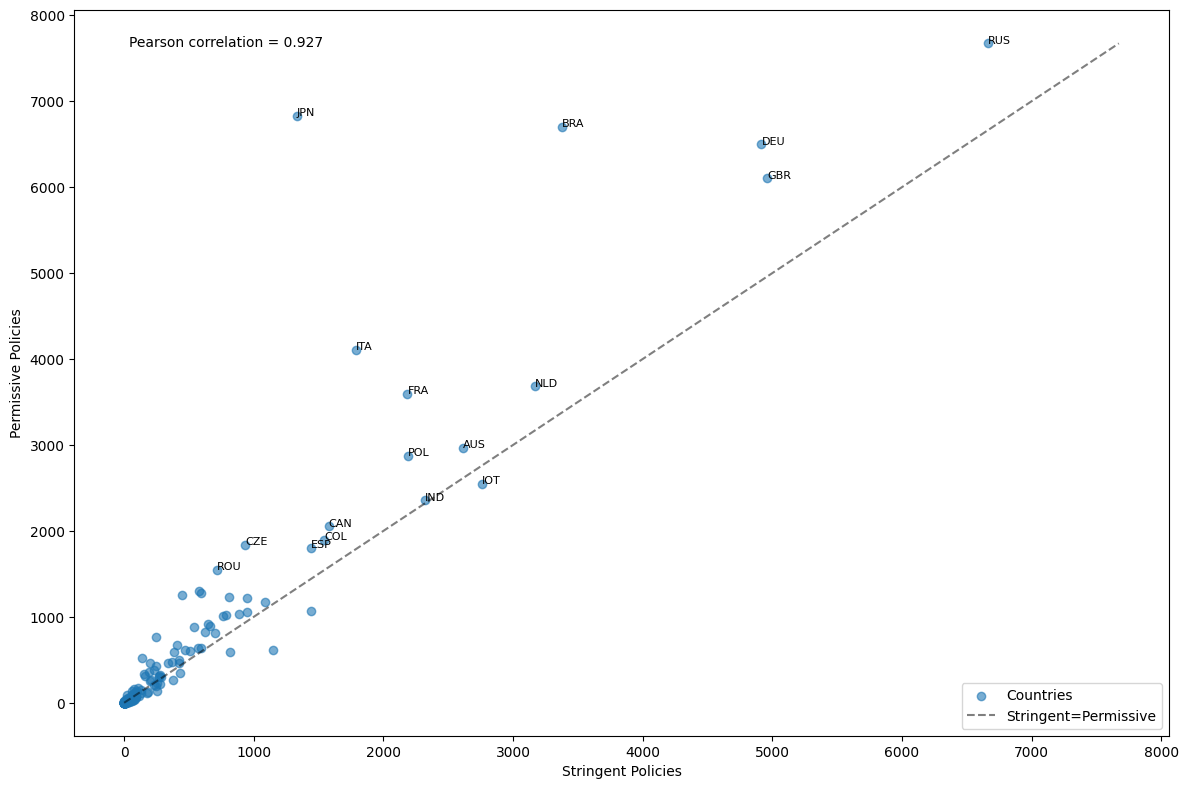

In [7]:
def strict_relaxed_policy_correlation(policy_counts_pdf, threshold, is_gov=False):

    plt.figure(figsize=(12, 8))
    plt.scatter(policy_counts_pdf['strict_policies'], policy_counts_pdf['relaxed_policies'], alpha=0.6, label='Countries')

    # Calculate Pearson correlation
    pearson_r, p_value = stats.pearsonr(policy_counts_pdf['strict_policies'], 
                                        policy_counts_pdf['relaxed_policies'])

    # Calculate regression line
    z = np.polyfit(policy_counts_pdf['strict_policies'], 
                policy_counts_pdf['relaxed_policies'], 1)
    p = np.poly1d(z)

    # Plot regression line
    #x_line = np.linspace(policy_counts_pdf['strict_policies'].min(), 
    #                     policy_counts_pdf['strict_policies'].max(), 1000)
    #plt.plot(x_line, p(x_line), "r--", alpha=0.8, 
    #         label=f'Pearson correlation={pearson_r:.3f}')
    plt.annotate(f'Pearson correlation = {pearson_r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction')

    # Add x=y reference line
    max_val = max(policy_counts_pdf['strict_policies'].max(), 
                  policy_counts_pdf['relaxed_policies'].max())
    min_val = min(policy_counts_pdf['strict_policies'].min(), 
                  policy_counts_pdf['relaxed_policies'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, 
            label=f'{STRICT.capitalize()}={RELAXED.capitalize()}')

    # Add labels for interesting points (optional)
    for idx, row in policy_counts_pdf.iterrows():
        if row['strict_policies'] > threshold or row['relaxed_policies'] > threshold:
            plt.annotate(row['country'], (row['strict_policies'], row['relaxed_policies']), fontsize=8)

    # Add legend with Pearson correlation in bottom right
    #legend_text = f'Pearson r = {pearson_r:.3f} (p = {p_value:.3f})'
    plt.legend(loc='lower right') #, title=legend_text, title_fontsize=12)

    plt.xlabel(f'{STRICT.capitalize()} Policies')
    plt.ylabel(f'{RELAXED.capitalize()} Policies')
    #plt.title(f'Strict vs Relaxed Policies by Country')
    plt.tight_layout()
    filename = 'figures/stringent_vs_permissive_policies_correlation.pdf'
    if is_gov:
        filename = 'figures/gov_stringent_vs_permissive_policies_correlation.pdf'
    plt.savefig(filename)
    plt.show()

strict_relaxed_policy_correlation(policy_counts_pdf.copy(), threshold=1500)

This view is from tranco, hence it may change from CT logs measurements.

The correlation means that the more domains adopt DMARC, they are likely having similar stringent and permissive policies in place. The plot shows a few countries with more stringent DMARC policy, for example IOT (.io -- British Indian Ocean Territory; not strictly to .io because is a double meaning domain) with a large DMARC adoption and with more stringent ones. A few notable cases: France, Italy, Japan and Brazil with large DMARC adoption but with more permissive policies. This graph is an indication of adoption first, enforcement later.

how does this change over time? are the countries moving from permissive to stringent policy?

Caveat: strictness per nr of domains ratio. Some domains have higher absolute counts which could bias the visualization.

ATF (0.83) - total: 12
COK (1.00) - total: 2
FLK (1.00) - total: 1
GLP (0.86) - total: 14
GMB (1.00) - total: 2
GRL (0.90) - total: 20
KNA (1.00) - total: 1
NER (0.83) - total: 12
NRU (1.00) - total: 2
TCD (1.00) - total: 3
WLF (1.00) - total: 2
YEM (1.00) - total: 1


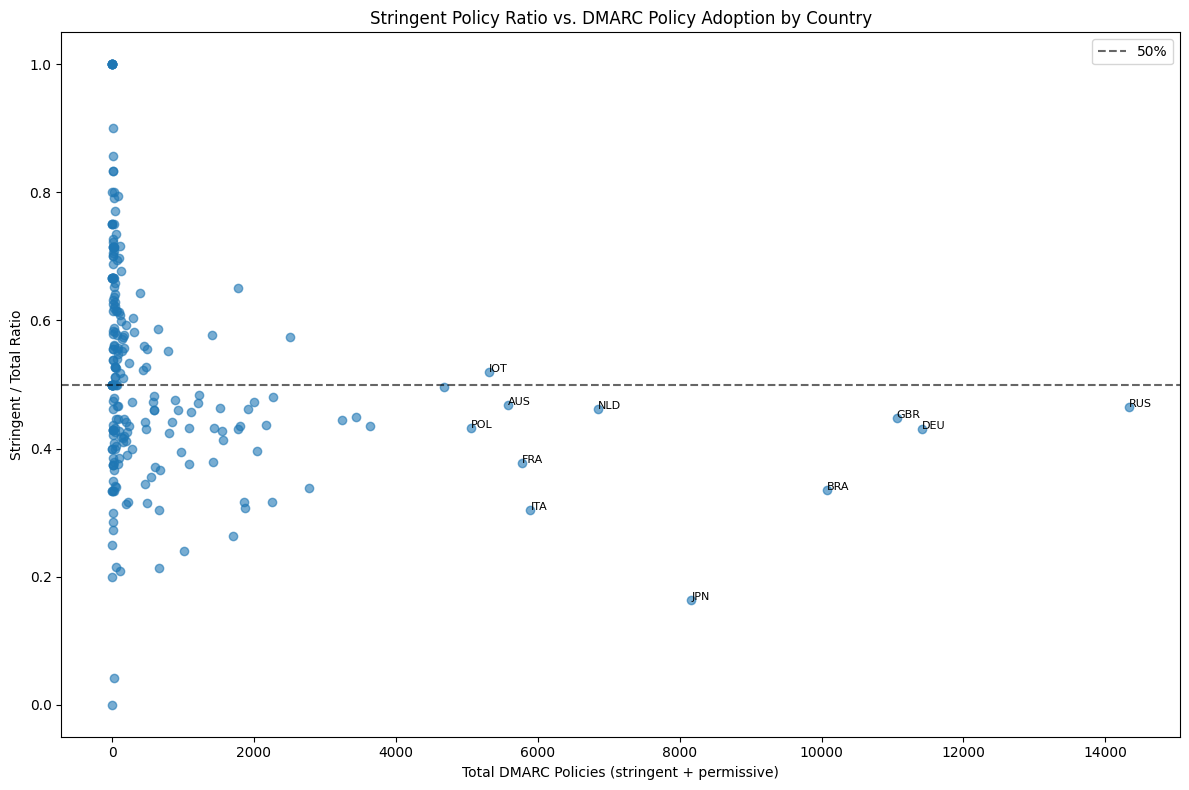

In [8]:
def strict_policy_correlation_ratio(policy_counts_pdf, threshold, is_gov=False):
    policy_counts_pdf['total_policies'] = (
        policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']
    )
    policy_counts_pdf['strict_ratio'] = (
        policy_counts_pdf['strict_policies'] / policy_counts_pdf['total_policies']
    )

    plt.figure(figsize=(12, 8))
    plt.scatter(policy_counts_pdf['total_policies'], 
                policy_counts_pdf['strict_ratio'], alpha=0.6)

    # Annotate major countries
    for idx, row in policy_counts_pdf.iterrows():
        if row['total_policies'] > threshold:  # same threshold you already use
            plt.annotate(row['country'], (row['total_policies'], row['strict_ratio']), fontsize=8)
        if row['strict_ratio'] > 0.8:
            print(f"{row['country']} ({row['strict_ratio']:.2f}) - total: {row['total_policies']}")

    plt.axhline(0.5, color='k', linestyle='--', alpha=0.6, label="50%")
    plt.xlabel(f"Total DMARC Policies ({STRICT} + {RELAXED})")
    plt.ylabel(f"{STRICT.capitalize()} / Total Ratio")
    plt.title(f"{STRICT.capitalize()} Policy Ratio vs. DMARC Policy Adoption by Country")
    plt.legend()
    plt.tight_layout()
    filename = 'figures/stringent_policy_ratio_vs_total_policies.pdf'
    if is_gov:
        filename = 'figures/gov_stringent_policy_ratio_vs_total_policies.pdf'
    plt.savefig(filename)
    plt.show()

strict_policy_correlation_ratio(policy_counts_pdf.copy(), threshold=5000)

High adoption doesn’t mean high strictness (e.g., Japan);
High strictness ratios usually come with low adoption;
Australia, Netherlands, Germany and Russia with a more balanced adoption.

Even countries with low adoption do a slow start with DMARC.

Smaller domain spaces where coordination is easier.

IOT (.io) is a corner case because the domain name have usage due to its double meaning name in computer science.

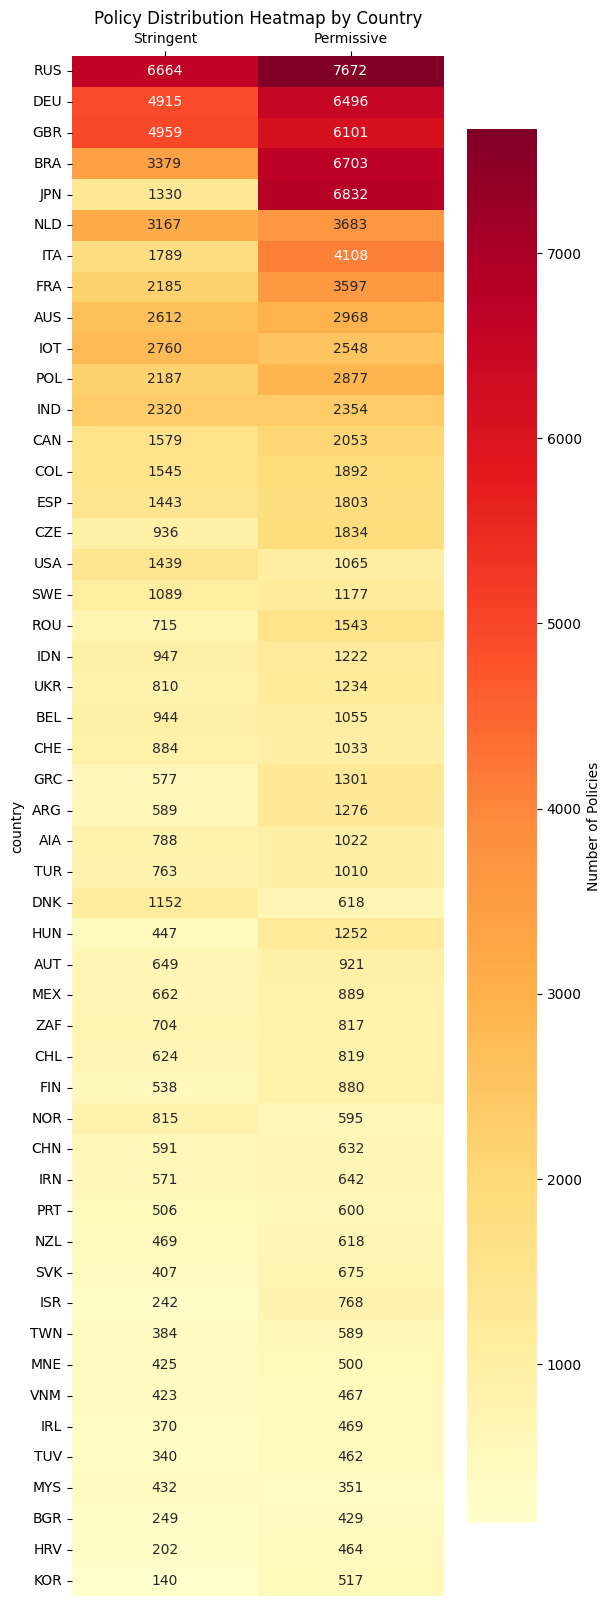

,country,percent_strict,strict_policies,relaxed_policies
175,RUS,46.484375,6664,7672
54,DEU,43.072474,4915,6496
72,GBR,44.837251,4959,6101
29,BRA,33.515176,3379,6703
104,JPN,16.295026,1330,6832


In [9]:
def policy_distribution_heatmap(policy_counts_pdf, top_n=50):
    # Reshape data for heatmap
    policy_counts_pdf['total_policies'] = (
        policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']
    )

    # sorting by total:
    policy_counts_pdf = policy_counts_pdf.sort_values(by='total_policies', ascending=False)

    heatmap_data = policy_counts_pdf.set_index('country')[['strict_policies', 'relaxed_policies']]
    heatmap_data = heatmap_data.rename(columns={
        'strict_policies': STRICT.capitalize(),
        'relaxed_policies': RELAXED.capitalize()
    })
    # Create heatmap (show top 50 for readability)
    plt.figure(figsize=(6, 20))
    sns.heatmap(heatmap_data.head(top_n), 
                annot=True, 
                fmt='d', 
                cmap='YlOrRd',
                cbar_kws={'label': 'Number of Policies'},
            )

    plt.title('Policy Distribution Heatmap by Country')
    plt.yticks(rotation=0)
    plt.gca().xaxis.tick_top()  # Move x-axis labels to top
    plt.gca().xaxis.set_label_position('top')  # Move x-axis label to top
    plt.show()
    policy_counts_pdf['percent_strict'] = policy_counts_pdf['strict_policies'] / policy_counts_pdf['total_policies'] * 100
    display(policy_counts_pdf.nlargest(5, 'total_policies')[["country", "percent_strict", "strict_policies", "relaxed_policies"]])

policy_distribution_heatmap(policy_counts_pdf.copy())

Low presence of US domains: the domains might be registered under .com, .net or .org TLDs for historical reasons.  

the most unbalanced is japan.

Most mature adopters (5,000+ policies) converge to:  
(table above)

the concentration of DMARC usage is in EU.

This 35-45% range appears to be the equilibrium for large-scale deployments, with Japan being the dramatic outlier at 16%.

In [10]:
def convert_alpha3_to_continent_code(alpha3: str):
    if alpha3 == "VAT":
        return "Europe"
    if alpha3 == 'ATF':
        return 'Antarctica'
    if alpha3 == 'TLS':
        return 'Asia'
    if alpha3 == 'PCN':
        return 'Oceania'
    if alpha3 == 'SXM':
        return 'North America'
    return convert_continent_code_to_continent_name(country_alpha2_to_continent_code(map_country_alpha3_to_country_alpha2()[alpha3.upper()]))

# Top X represents 80% of total policies
def most_dmarc_users(policy_counts_pdf):
    policy_counts_pdf['total_policies'] = (
        policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']
    )
    policy_counts_pdf = policy_counts_pdf.sort_values(by='total_policies', ascending=False)  # Largest first
    policy_counts_pdf["cdf"] = policy_counts_pdf['total_policies'].cumsum() / policy_counts_pdf['total_policies'].sum()

    # If you want to include the first country that pushes it over 80%:
    # Find the index where we cross 80%
    idx_80 = (policy_counts_pdf["cdf"] > 0.8).idxmax()
    top_80_percent_inclusive = policy_counts_pdf.loc[:idx_80]
    display(top_80_percent_inclusive[['country', 'strict_policies', 'relaxed_policies', 'total_policies']])

    print(f"Number of countries representing 80% of DMARC adoption: {len(top_80_percent_inclusive)}")
    print(f"These {len(top_80_percent_inclusive)} countries out of {len(policy_counts_pdf)} total countries represent 80% of global DMARC adoption")

    policy_counts_pdf.loc[:, 'continent'] = policy_counts_pdf['country'].apply(lambda x: convert_alpha3_to_continent_code(x))
    # groupby continent
    display(
        policy_counts_pdf.groupby('continent')[['strict_policies', 'relaxed_policies', 'total_policies']].sum().sort_values(by='total_policies', ascending=False)
    )


most_dmarc_users(policy_counts_pdf.copy())

,country,strict_policies,relaxed_policies,total_policies
175,RUS,6664,7672,14336
54,DEU,4915,6496,11411
72,GBR,4959,6101,11060
29,BRA,3379,6703,10082
104,JPN,1330,6832,8162
153,NLD,3167,3683,6850
100,ITA,1789,4108,5897
68,FRA,2185,3597,5782
13,AUS,2612,2968,5580
94,IOT,2760,2548,5308


Number of countries representing 80% of DMARC adoption: 33
These 33 countries out of 232 total countries represent 80% of global DMARC adoption


,strict_policies,relaxed_policies,total_policies
continent,,,
Europe,41083,55519,96602
Asia,14519,21358,35877
South America,6975,11493,18468
North America,5134,5459,10593
Oceania,3748,4455,8203
Africa,1691,2040,3731
Antarctica,10,2,12


In [11]:
# https://www.iban.com/country-codes
# South Sudan (.ss; SSD) cannot be displayed in the world graph

def world_plot_ratio(copy_policy_counts_pdf):
    # Calculate percentage of strict policies for hover info
    copy_policy_counts_pdf['pct_strict'] = (copy_policy_counts_pdf['strict_policies'] / copy_policy_counts_pdf['total_policies']) * 100

    # Create the choropleth map
    fig = px.choropleth(copy_policy_counts_pdf,
                        locations='country',  # Your 3-letter country codes
                        locationmode='ISO-3',
                        color='ratio',
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'total_policies': ':,',
                            'pct_strict': ':.1f',
                            'ratio': ':.2f'
                        },
                        color_continuous_scale='RdBu_r',  # Red for high ratio (more strict), Blue for low
                        labels={
                            'ratio': f'{STRICT.capitalize()}/{RELAXED.capitalize()} Ratio',
                            'strict_policies': f'{STRICT.capitalize()} Policies',
                            'relaxed_policies': f'{RELAXED.capitalize()} Policies',
                            'total_policies': 'Total Policies',
                            'pct_strict': f'% {STRICT.capitalize()}'
                        },
                        title='DMARC Policy Ratio by Country')

    # Update layout for better visualization
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        coloraxis_colorbar=dict(
            title=f"{STRICT.capitalize()}/{RELAXED.capitalize()}<br>Ratio",
            tickmode='linear',
            tick0=0,
            dtick=0.5,
            len=0.7,
            thickness=15
        ),
        height=700,
        title={
            'text': 'DMARC Policy Ratio by Country',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        }
    )

    # Customize hover template
    fig.update_traces(
        hovertemplate='<b>%{hovertext}</b><br>' +
                    '{STRICT} Policies: %{customdata[0]}<br>' +
                    '{RELAXED} Policies: %{customdata[1]}<br>' +
                    'Total Policies: %{customdata[2]}<br>' +
                    'Percent Strict: %{customdata[3]:.1f}%<br>' +
                    'Ratio: %{customdata[4]:.2f}<extra></extra>'
    )

    fig.show()

def world_plot_differences(copy_policy_counts_pdf):
    # Use the 3-letter ISO codes for the map
    fig2 = px.choropleth(copy_policy_counts_pdf,
                                locations='country',
                                locationmode='ISO-3',
                                color='difference',
                                hover_name='country',
                                hover_data={
                                    'strict_policies': ':,',
                                    'relaxed_policies': ':,',
                                    'difference': ':,'
                                },
                                color_continuous_scale='RdBu_r',
                                color_continuous_midpoint=0,
                                range_color=[copy_policy_counts_pdf['difference'].min(),
                                            copy_policy_counts_pdf['difference'].max()],
                                labels={'difference': 'Policy Difference'},
                                title=f'DMARC Policy Difference by Country (Red=More {STRICT.capitalize()}, Blue=More {RELAXED.capitalize()})')

    fig2.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=700,
    )

    fig2.show()

def world_plot_ratio_categories(copy_policy_counts_pdf, is_gov=False):
    # Optional: Create intervals for categorical coloring
    highest_ratio = copy_policy_counts_pdf['ratio'].max()
    l = f'{STRICT.capitalize()}/{RELAXED.capitalize()} policy ratio categories'

    intervals = [0.0, 0.5, 1.0, 2.0, highest_ratio]

    # Define the category labels in the order you want them
    category_labels = [
        f'Mostly {RELAXED.capitalize()} ({intervals[0]}:{intervals[1]}]',
        f'Balanced-{RELAXED.capitalize()} ({intervals[1]}:{intervals[2]}]',
        f'Balanced-{STRICT.capitalize()} ({intervals[2]}:{intervals[3]}]',
        f'Mostly {STRICT.capitalize()} ({intervals[3]}:{intervals[4]}]'
    ]

    copy_policy_counts_pdf[l] = pd.cut(copy_policy_counts_pdf['ratio'],
                                            bins=intervals,
                                            labels=category_labels)

    fig3 = px.choropleth(copy_policy_counts_pdf,
                        locations='country',
                        locationmode='ISO-3',
                        color=l,
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'ratio': ':.2f'
                        },
                        color_discrete_map={
                            category_labels[0]: '#2166ac',
                            category_labels[1]: '#92c5de', 
                            category_labels[2]: '#f4a582',
                            category_labels[3]: '#b2182b'  # Use the dynamic label
                        },
                        category_orders={l: category_labels},
                        #title='DMARC Policy Categories by Country'
                        )

    fig3.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        #height=700,
        legend=dict(
            orientation='h',
            yanchor='top',
            y=0.1,
            xanchor='center',
            x=0.5,
            title=dict(           # legend title styling
                text=l,
                side="top"        # keep title on top of the items
            )
        ),
        margin=dict(l=0, r=0, t=0, b=0)  # minimal whitespace
    )

    filename = "figures/world_map_policy_ratio_category.pdf"
    if is_gov:
        filename = "figures/gov_world_map_policy_ratio_category.pdf"
    fig3.write_image(filename, height=700, width=1000)
    fig3.show()


def world_plot_percentage(copy_policy_counts_pdf, is_gov=False):
    # Calculate the percentage of strict and relaxed policies
    copy_policy_counts_pdf['strict_percentage'] = (copy_policy_counts_pdf['strict_policies'] / copy_policy_counts_pdf['total_policies']) * 100
    copy_policy_counts_pdf['relaxed_percentage'] = (copy_policy_counts_pdf['relaxed_policies'] / copy_policy_counts_pdf['total_policies']) * 100

    fig4 = px.choropleth(copy_policy_counts_pdf,
                        locations='country',
                        locationmode='ISO-3',
                        color='strict_percentage',
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'strict_percentage': ':.2f',
                            'relaxed_percentage': ':.2f'
                        },
                        color_continuous_scale='RdBu_r',
                        color_continuous_midpoint=0,
                        range_color=[copy_policy_counts_pdf['strict_percentage'].min(),
                                    copy_policy_counts_pdf['strict_percentage'].max()],
                        labels={'strict_percentage': f'{STRICT.capitalize()} Policy %'},
                        #title=f'DMARC {STRICT.capitalize()} Policy Percentage by Country'
                        )

    fig4.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        #height=700,
        margin=dict(l=0, r=0, t=0, b=0),
        coloraxis_colorbar=dict(
            title=f'{STRICT.capitalize()}<br>Policy (%)',
            len=0.6,       # scale bar length (0–1 of figure height)
            thickness=15,  # thickness in px
            yanchor="middle",
            y=0.5          # center it vertically
        ),
    )
    filename = "figures/world_map_stringent_policy_percentage.pdf"
    if is_gov:
        filename = "figures/gov_world_map_stringent_policy_percentage.pdf"
    fig4.write_image(filename, height=700, width=1000)
    fig4.show()

world_plot_percentage(policy_counts_pdf.copy())
world_plot_ratio_categories(policy_counts_pdf.copy())
#world_plot_ratio(policy_counts_pdf.copy())
#world_plot_differences(policy_counts_pdf.copy())

many digitally advanced nations (Germany, Japan, Brazil, UK) have mostly permissive policies, while some less digitally prominent nations show stringent policies.  

South Africa has a higher adoption in Africa
Asia has as few big users of DMARC like Japan, with high adoption but more on the permissive policy.  
Countries with more strict DMARC policies also are with less DMARC adoption.  


### government domains

In [12]:
gov_cctld_dmarc_pdf = cctld_dmarc_pdf[cctld_dmarc_pdf['tld'].str.contains('gov')]

In [13]:
gov_policy_counts_pdf = get_aggr_policy_count_per_country(gov_cctld_dmarc_pdf.copy())

wrongly assigned countries:
0


Distribution of government domains

In [14]:
# statistics of how many gov domain with respect to all domains per country, ordered by total gov domains of each country
def show_gov_per_country(cctld_dmarc_pdf):
    agg_pdf = cctld_dmarc_pdf.groupby(['country', "is_gov"]).size().reset_index(name='count')
    country_breakdown = agg_pdf.groupby(['country', 'is_gov'])['count'].sum().reset_index()

    # Pivot to get government and non-government columns
    country_pivot = country_breakdown.pivot(index='country', columns='is_gov', values='count').fillna(0)

    # Rename columns for clarity
    country_pivot.columns = ['non_gov_count', 'gov_count']

    # Calculate total domains per country
    country_pivot['total_count'] = country_pivot['non_gov_count'] + country_pivot['gov_count']

    # Calculate percentages
    country_pivot['gov_percentage'] = (country_pivot['gov_count'] / country_pivot['total_count'] * 100).round(2)
    country_pivot['non_gov_percentage'] = (country_pivot['non_gov_count'] / country_pivot['total_count'] * 100).round(2)

    # Reset index to make country a regular column
    country_pivot = country_pivot.reset_index()

    # Sort by government percentage in descending order
    country_pivot = country_pivot.sort_values('gov_percentage', ascending=False)
    display(country_pivot[["country", "gov_count", "gov_percentage", "total_count"]].head(10))

show_gov_per_country(cctld_dmarc_pdf.copy())

,country,gov_count,gov_percentage,total_count
67,FLK,1.0,100.00,1.0
77,GIN,2.0,66.67,3.0
217,USA,1417.0,56.59,2504.0
32,BTN,9.0,50.00,18.0
30,BRB,3.0,50.00,6.0
115,LBR,1.0,50.00,2.0
101,JAM,10.0,47.62,21.0
20,BGD,140.0,47.46,295.0
158,OMN,23.0,43.40,53.0
108,KHM,17.0,39.53,43.0


ValueError: `x` and `y` must have length at least 2.

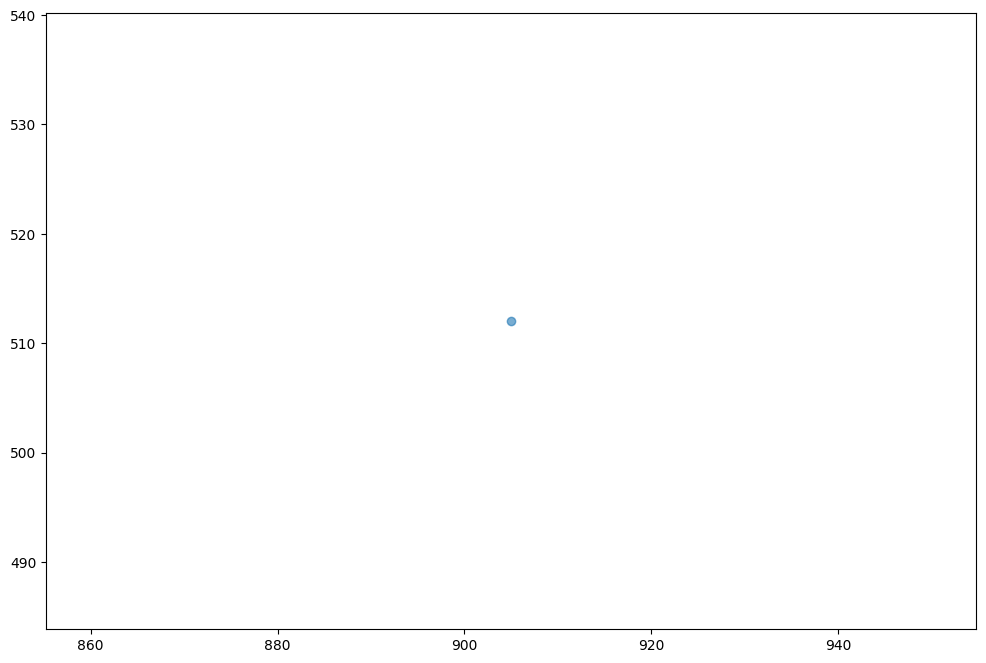

In [15]:
strict_relaxed_policy_correlation(gov_policy_counts_pdf.copy(), threshold=100, is_gov=True)

AUS (0.81) - total: 380
AZE (0.97) - total: 33
BHS (1.00) - total: 2
BIH (0.86) - total: 7
BLR (0.88) - total: 25
BLZ (1.00) - total: 2
BWA (1.00) - total: 1
FJI (1.00) - total: 2
GBR (0.86) - total: 548
HKG (0.91) - total: 103
IND (0.95) - total: 677
IRN (0.81) - total: 16
JOR (0.92) - total: 26
LVA (0.96) - total: 27
MNE (1.00) - total: 1
MNG (0.92) - total: 12
NAM (1.00) - total: 1
NLD (1.00) - total: 1
QAT (0.86) - total: 22
SAU (0.81) - total: 108
SDN (1.00) - total: 1
SGP (0.85) - total: 114
SHN (1.00) - total: 1
SYR (1.00) - total: 1
TKM (1.00) - total: 4
TUN (1.00) - total: 2
ZWE (1.00) - total: 2


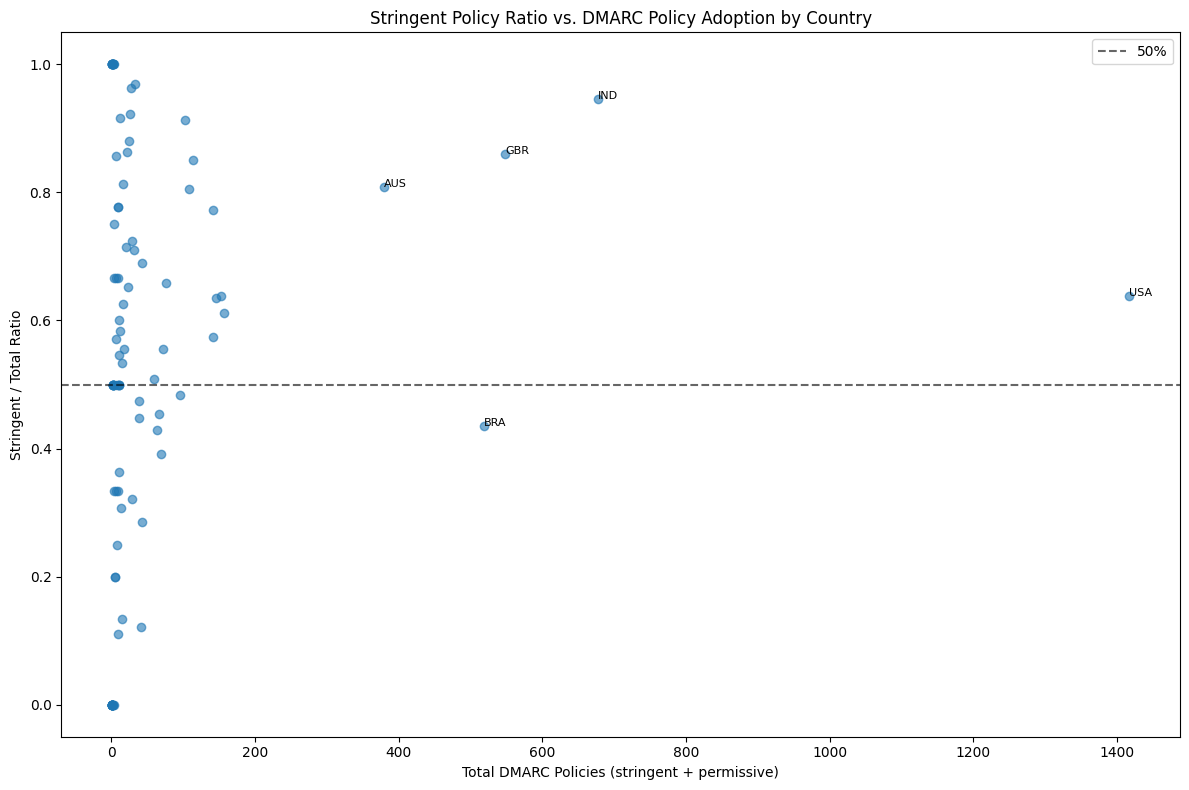

In [ ]:
strict_policy_correlation_ratio(gov_policy_counts_pdf.copy(), threshold=200, is_gov=True)

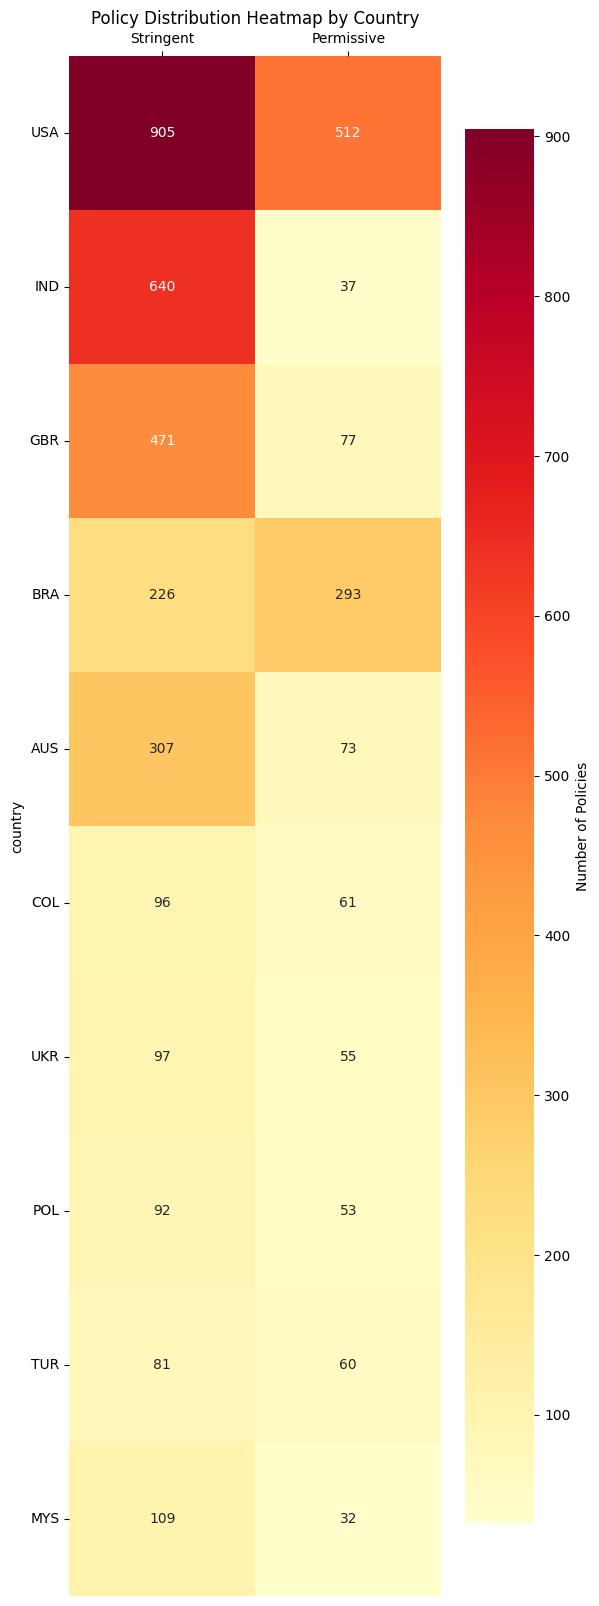

,country,percent_strict,strict_policies,relaxed_policies
95,USA,63.867325,905,512
38,IND,94.534712,640,37
30,GBR,85.948905,471,77
13,BRA,43.545279,226,293
5,AUS,80.789474,307,73


In [ ]:
policy_distribution_heatmap(gov_policy_counts_pdf.copy(), 10)

In [ ]:
most_dmarc_users(gov_policy_counts_pdf.copy())

,country,strict_policies,relaxed_policies,total_policies
95,USA,905,512,1417
38,IND,640,37,677
30,GBR,471,77,548
13,BRA,226,293,519
5,AUS,307,73,380
21,COL,96,61,157
94,UKR,97,55,152
73,POL,92,53,145
92,TUR,81,60,141
65,MYS,109,32,141


Number of countries representing 80% of DMARC adoption: 15
These 15 countries out of 100 total countries represent 80% of global DMARC adoption


,strict_policies,relaxed_policies,total_policies
continent,,,
Asia,1490,496,1986
North America,916,519,1435
Europe,776,261,1037
South America,394,414,808
Oceania,339,103,442
Africa,102,100,202


In [ ]:
world_plot_percentage(gov_policy_counts_pdf.copy(), is_gov=True)
world_plot_ratio_categories(gov_policy_counts_pdf.copy(), is_gov=True)

In [ ]:
print_statistics(gov_policy_counts_pdf.copy())


=== DMARC Policy Ratio Statistics ===
Countries with more stringent than permissive (ratio > 1): 47
Countries with more permissive than stringent (ratio <= 1): 53

Mean ratio: 2.48

Top 5 stringent countries (by ratio):
   country      ratio  strict_policies  relaxed_policies
6      AZE  32.000000               32                 1
53     LVA  26.000000               26                 1
38     IND  17.297297              640                37
44     JOR  12.000000               24                 2
61     MNG  11.000000               11                 1

Top 5 most permissive countries (by ratio):
   country  ratio  strict_policies  relaxed_policies
1      AGO    0.0                0                 1
7      BFA    0.0                0                 1
20     CMR    0.0                0                 3
23     DMA    0.0                0                 1
27     EST    0.0                0                 1

Percent of stringent policies: 68.0%
Percent of permissive policies: 32.0

## Graph Analysis

### Neo4j connection

In [16]:
class Neo4jConnection:
    def __init__(self, uri, user, password):
        self.uri = uri
        self.user = user
        self.password = password
        self.driver = None

    def __enter__(self):
        """Enter the context manager - establish connection"""
        self.driver = GraphDatabase.driver(self.uri, auth=(self.user, self.password))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Exit the context manager - close connection"""
        if self.driver:
            self.driver.close()

    def test_connection(self):
        with self.driver.session() as session:
            result = session.run("RETURN 'Connection successful' as message")
            print(result.single()["message"])

    def query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]

    def query_to_df(self, query, parameters=None):
        results = self.query(query, parameters)
        return pd.DataFrame(results)

    def write_query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return result.consume().counters

load_dotenv()
NEO4J_PASSWD = os.getenv('NEO4J_PASSWD')
if not NEO4J_PASSWD:
    raise ValueError("NEO4J_PASSWD not found in environment variables")

URI = "bolt://localhost:7687"
AUTH = ("neo4j", NEO4J_PASSWD)

Warning! RUN THIS ONLY ONCE TO SET UP THE DATABASE

In [ ]:
with Neo4jConnection(URI, *AUTH) as conn:
    conn.test_connection()
    conn.write_query("CREATE INDEX vertices_id_index IF NOT EXISTS FOR (n:Vertices) ON (n.id)")
    conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///vertices.csv" AS row
            CREATE (:Vertices {id: row.id, is_gov: row.is_gov, domain_type: row.domain_type, country: row.country})
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    result = conn.query("MATCH (n:Vertices) RETURN count(n) as total_vertices")
    print(f"Total vertices in database: {result[0]['total_vertices']}")

    result_rua = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///edges.csv" AS row
            WITH row WHERE row.edge_type = "rua"
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:rua]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"rua edges created: {result_rua.relationships_created}")

    result_ruf = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///edges.csv" AS row
            WITH row WHERE row.edge_type = "ruf"
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:ruf]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"ruf edges created: {result_ruf.relationships_created}")

    current_graphs = conn.query("""
        CALL gds.graph.list()
        YIELD graphName, nodeCount, relationshipCount
        RETURN graphName, nodeCount, relationshipCount
        ORDER BY graphName
    """)

    if current_graphs:
        print("Current graph projections:")
        for graph in current_graphs:
            print(f"  {graph['graphName']}: {graph['nodeCount']} nodes, {graph['relationshipCount']} relationships")
        if False: # delete graph!
            for graph in current_graphs:
                conn.write_query(f"CALL gds.graph.drop({graph['graphName']}) YIELD graphName;")
                print(f"Dropped existing graph projection {graph['graphName']}.")
    else:
        conn.write_query("""
            CALL gds.graph.project(
                'DMARC',
                'Vertices',
                ['rua', 'ruf']
            )
        """)

#  DMARC: 439947 nodes, 473493 relationships
# tranco, no cctld filter
#Total vertices in database: 439947
#rua edges created: 315274
#ruf edges created: 158219
# cctld filter:
#Total vertices in database: 181859
#rua edges created: 125719
#ruf edges created: 62604

Connection successful
Total vertices in database: 181859
rua edges created: 125719
ruf edges created: 62604


below will clean up the database... be careful!

In [17]:
def nodes_in_database(conn):
    result = conn.query("""
        MATCH (n)
        RETURN count(n) AS node_count
    """)
    print(f"Total nodes in database: {result[0]['node_count']}")
    result = conn.query("""
        MATCH ()-[r]-()
        RETURN count(r) AS relationship_count
    """)
    print(f"Total relationships in database: {result[0]['relationship_count']}")

# cleaning up the database
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    conn.test_connection()
    print("before the clean up")
    nodes_in_database(conn)

    try:
        conn.query("""
            CALL gds.graph.drop('DMARC')
        """)
    except Exception as e:
        print(f"Error dropping graph: {e}")

    conn.query("""
        MATCH ()-[r]-()
        DELETE r;
    """)

    conn.query("""
        MATCH (n)
        DELETE n;
    """)

    print("after the clean up")
    nodes_in_database(conn)


Connection successful
before the clean up
Total nodes in database: 181626
Total relationships in database: 293482


WARNING	Task(Task-2) neo4j.notifications:result.py:_handle_warnings()- Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The procedure has a deprecated field. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 2, column: 13, offset: 13} for query: "\n            CALL gds.graph.drop('DMARC')\n        "


after the clean up
Total nodes in database: 0
Total relationships in database: 0


Best visualized at cypher using:  

MATCH (n:Vertices)-[r]-(m:Vertices)  
RETURN n, r, m  
LIMIT 50;  


Visualize individual nodes:  

MATCH (n:Vertices)-[r]-(m:Vertices)  
WHERE n.id = "bibleminute.co"  
RETURN n, r, m  

##### Local visualization -- not good

In [ ]:
def visualize_with_existing_connection(conn, query, limit=50):
    # Get data using your existing connection
    data = conn.query(f"{query} LIMIT {limit}")

    # Create NetworkX graph
    G = nx.DiGraph()  # Directed graph for rua/ruf relationships

    # Process the data
    for record in data:
        if 'source' in record and 'target' in record:
            G.add_edge(record['source'], record['target'], 
                      rel_type=record.get('relationship', 'CONNECTED'))

    # Visualization
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Different colors for different relationship types
    edge_colors = []
    for u, v, d in G.edges(data=True):
        if d.get('rel_type') == 'rua':
            edge_colors.append('red')
        elif d.get('rel_type') == 'ruf':
            edge_colors.append('blue')
        else:
            edge_colors.append('gray')

    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_color='lightgreen', 
                          node_size=300, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, 
                          arrows=True, arrowsize=20, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold')

    plt.title(f"Graph Visualization ({len(G.nodes())} nodes, {len(G.edges())} edges)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print stats
    print(f"Nodes: {len(G.nodes())}")
    print(f"Edges: {len(G.edges())}")

    return G

# horrible visualization; no other better python choice... use cypher which is better
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # Query that returns source, target, relationship
    query = """
        MATCH (n:Vertices)-[r]->(m:Vertices)
        RETURN n.id as source, m.id as target, type(r) as relationship
    """

    graph = visualize_with_existing_connection(conn, query, limit=50)

### Connected Components algorithm

In [36]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    result_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        RETURN  componentId, 
                collect(gds.util.asNode(nodeId).id) AS node_ids,
                size(collect(gds.util.asNode(nodeId).id)) AS component_size
        ORDER BY size(node_ids) DESC
        LIMIT 10;
    """)
    display(result_pdf)

,componentId,node_ids,component_size
0,5,"[ballast-nedam.nl, saib.com.sa, companymobile....",46760
1,2668,"[idera.com, youtube.com.eg, google.td, google....",461
2,5650,"[millevertus.ca, dressageanival.ca, bijouterie...",168
3,3417,"[nabytkomanie.cz, permaseminka.cz, essenseurop...",142
4,3541,"[f-b.no, aasanetidende.no, gd.no, hardanger-fo...",91
5,1645,"[dmarc.microsoft, aka.ms, sharepoint.de, offic...",85
6,3188,"[bmw-motorrad.de, mini.fi, mini.com.mx, bmw.ca...",79
7,5440,"[iib.gov.in, bharatpetroleum.in, mothercare.in...",70
8,11734,"[pausetoujours.fr, actu-economique.fr, objecti...",64
9,4013,"[va.se, dagenssamhalle.se, vlt.se, dalademokra...",60


In [51]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    clusters_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        WITH componentId, collect(gds.util.asNode(nodeId).id) AS node_ids
        WHERE size(node_ids) > 1  // Only multi-node components

        // For each component, get top n most connected nodes
        UNWIND node_ids AS node_id
        MATCH (target:Vertices {id: node_id})
        OPTIONAL MATCH (source:Vertices)-[r:rua|ruf]->(target)
        WHERE source.id IN node_ids
        WITH componentId, node_ids, target.id AS vertex_id, count(r) AS incoming_count
        ORDER BY componentId, incoming_count DESC

        // Get top 5 nodes per component
        //WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count})[0..5] AS top_nodes
        WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count}) AS top_nodes

        RETURN componentId,
            size(node_ids) AS component_size,
            top_nodes
        ORDER BY component_size DESC
        //LIMIT 10;
    """)
    display(clusters_pdf)

,componentId,component_size,top_nodes
0,5,46760,"[{'incoming': 6790, 'vertex': 'proofpoint.com'..."
1,2668,461,"[{'incoming': 459, 'vertex': 'google.com'}, {'..."
2,5650,168,"[{'incoming': 168, 'vertex': 'votresite.ca'}, ..."
3,3417,142,"[{'incoming': 284, 'vertex': 'leadhub.co'}, {'..."
4,3541,91,"[{'incoming': 91, 'vertex': 'amedia.no'}, {'in..."
...,...,...,...
8417,161404,2,"[{'incoming': 4, 'vertex': 'sevenkeys.com.br'}..."
8418,161776,2,"[{'incoming': 1, 'vertex': 'verkaufen.ch'}, {'..."
8419,162550,2,"[{'incoming': 1, 'vertex': 'singleinterface.co..."
8420,166734,2,"[{'incoming': 2, 'vertex': 'gibilogic.com'}, {..."


In [ ]:
# row 6 is tripadvisor
display(clusters_pdf["top_nodes"].iloc[5])

[{'incoming': 143, 'vertex': 'tripadvisor.com'},
 {'incoming': 0, 'vertex': 'housetrip.com'},
 {'incoming': 0, 'vertex': 'flipkey.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.co.kr'},
 {'incoming': 0, 'vertex': 'tripadvisor.ca'},
 {'incoming': 0, 'vertex': 'cruisecritic.com.au'},
 {'incoming': 0, 'vertex': 'tripadvisor.cn'},
 {'incoming': 0, 'vertex': 'viatorsystems.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.cl'},
 {'incoming': 0, 'vertex': 'cruisecritic.co.uk'},
 {'incoming': 0, 'vertex': 'thefork.it'},
 {'incoming': 0, 'vertex': 'tripadvisor.jp'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.eg'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.vn'},
 {'incoming': 0, 'vertex': 'tripadvisor.at'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.tr'},
 {'incoming': 0, 'vertex': 'thefork.nl'},
 {'incoming': 0, 'vertex': 'tripadvisor.de'},
 {'incoming': 0, 'vertex': 'tripadvisorsupport.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.sg'},
 {'incoming': 0, 'vertex': 'tripadvisor.sk'},
 {'i

In [82]:
display(clusters_pdf["top_nodes"].iloc[2])

[{'incoming': 216, 'vertex': 'bmwgroup.com'},
 {'incoming': 0, 'vertex': 'bmw.hu'},
 {'incoming': 0, 'vertex': 'alphabet.pl'},
 {'incoming': 0, 'vertex': 'mini.es'},
 {'incoming': 0, 'vertex': 'mini.my'},
 {'incoming': 0, 'vertex': 'mini.co.kr'},
 {'incoming': 0, 'vertex': 'bmwlat.com'},
 {'incoming': 0, 'vertex': 'mini.dk'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.fr'},
 {'incoming': 0, 'vertex': 'bmw.be'},
 {'incoming': 0, 'vertex': 'mini.de'},
 {'incoming': 0, 'vertex': 'bmw.lu'},
 {'incoming': 0, 'vertex': 'bmw-welt.com'},
 {'incoming': 0, 'vertex': 'bmwgroupfs.com'},
 {'incoming': 0, 'vertex': 'bmw.no'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.es'},
 {'incoming': 0, 'vertex': 'bmw.in'},
 {'incoming': 0, 'vertex': 'mini.no'},
 {'incoming': 0, 'vertex': 'bmw.ca'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.de'},
 {'incoming': 0, 'vertex': 'bmw.ch'},
 {'incoming': 0, 'vertex': 'mini.com'},
 {'incoming': 0, 'vertex': 'mini.in'},
 {'incoming': 0, 'vertex': 'bmwgroupdesignworks.com'},
 

Visualization of specific components

// First, get the node IDs for component 2  
CALL gds.wcc.stream('DMARC', {relationshipTypes: ['rua', 'ruf']})  
YIELD nodeId, componentId  
WHERE componentId = 2  
WITH collect(gds.util.asNode(nodeId).id) AS component_nodes  

// Then visualize those nodes and their relationships  
MATCH (n:Vertices)  
WHERE n.id IN component_nodes  
MATCH (n)-[r:rua|ruf]-(m:Vertices)  
WHERE m.id IN component_nodes  
RETURN n, r, m;  

What are the small clusters?  
Business relationships: subsidiaries sending dmarc report to their holding's mailbox.

If you own multiple domains, it makes sense that all rua and ruf reports are sent to the IT security mailbox, either the holding company, the regional domain or to a 3rd party processor. For instance, regional tripadvisor such as tripadvisor.be send reports to its main region tripadvisor.com. Also, housetrip.com seems a subsidiary of tripadvisor, which also send dmarc reports to tripadvisor.com. The holding company doesn't use any specialized mail security company, and hence, handles the reports in-house.

Although in this example the companies are under the group, they may be in different countries and hence, different data jurisdictions apply.

The "holding", where the reports are sent, can turn into a target because it concentrates information

Can we distinguish subsidiaries and holdings automatically? maybe only using a web crawler...

Are the small clusters sending the report to the same data protection law?

#### Strongly Connected Components

"finds sets of connected nodes in a directed graph where each node is reachable in both directions from any other node in the same set"

In [ ]:
with Neo4jConnection(URI, *AUTH) as conn:
    scc_pdf = conn.query_to_df("""
        CALL gds.scc.stream("DMARC", {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        WITH componentId, count(nodeId) AS component_size
        RETURN component_size AS ComponentSize, count(*) AS NumberOfComponentsWithThisSize
        ORDER BY ComponentSize DESC
    """)
    display(scc_pdf)

    scc_pdf = conn.query_to_df("""
        CALL gds.scc.stream("DMARC", {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        RETURN componentId, collect(gds.util.asNode(nodeId).id) AS domains
        ORDER BY size(domains) DESC
        LIMIT 20
    """)
    display(scc_pdf)

,ComponentSize,NumberOfComponentsWithThisSize
0,2,17
1,1,439913


,componentId,domains
0,129612,"[birtema.com, temadam.com]"
1,30221,"[ciwf.org, ciwf.org.uk]"
2,62656,"[lukfook.com, jw28.com]"
3,106764,"[metalmarket.eu, metalmarket.eu]"
4,253374,"[peoplefluent.com, peopleclick.com]"
5,412070,"[bit.ly, bitly.net]"
6,24883,"[nuc.co.kr, kuvings.com]"
7,59742,"[kbtg.tech, kasikornbank.com]"
8,101337,"[netservicesgroup.net, netservicesgroup.com]"
9,352522,"[jetmailx.com.br, tavola.com.br]"


Only 17 cases have a 2 domain components that are strongly connected, ie, can reach each other (point to each other). All the other domains are not strongly connected. But we can find communities in them by looking at (weakly) connected components.

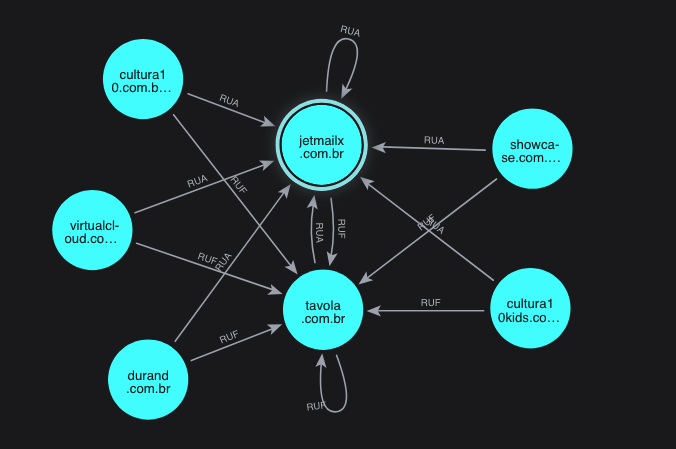

### Degree Centrality algorithm

"The degree centrality measures the number of incoming or outgoing (or both) relationships from a node, which can be defined by the orientation of a relationship projection. If a projection contains directed relationships, only outgoing relationships of a node are counted (the out-degree)." -- https://neo4j.com/docs/graph-data-science/current/algorithms/degree-centrality/  


In [51]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # this is calculating the outdegree centrality, ie the top 10 domains that send rua/ruf reports to most distinct domains
    print("Calculating degree centrality using out-degree...")
    outdegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_outgoing_links
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 10;
    """)
    display(outdegree_pdf)

    print("Calculating degree centrality using in-degree...")
    indegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC', { orientation: 'REVERSE' })
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_incoming_links
        ORDER BY nr_incoming_links DESC, domains DESC
        LIMIT 10;
    """)
    display(indegree_pdf)

Calculating degree centrality using out-degree...


,domains,nr_outgoing_links
0,minsa.gob.pe,7.0
1,mim.gov.sa,7.0
2,ikea.com.sa,7.0
3,geld.nl,7.0
4,y.co,6.0
5,wordans.ca,6.0
6,wits.ac.za,6.0
7,vvsg.be,6.0
8,vuurenrook.nl,6.0
9,vaxjo.se,6.0


Calculating degree centrality using in-degree...


,domains,nr_incoming_links
0,proofpoint.com,6794.0
1,dmarc-reports.cloudflare.net,6421.0
2,vali.email,4684.0
3,dmarcanalyzer.com,3791.0
4,dmarcian.com,3613.0
5,brevo.com,3227.0
6,dmarcadvisor.com,2992.0
7,mailinblue.com,2686.0
8,dmarc-report.com,2356.0
9,postmarkapp.com,2090.0


In [53]:
def add_external_domains_to_pdf(row, src_column, dst_column):
    """Add a column to the DataFrame indicating if the outgoing links are to external domains."""
    src_domain = row[src_column]
    dst_domains = set(row[dst_column])
    row['external_domains'] = []
    for dst_domain in dst_domains:
        # Check if the destination domain is external
        if not dst_domain.endswith(src_domain):
            row['external_domains'] = row.get('external_domains', []) + [dst_domain]

    row['nr_external_domains'] = len(row['external_domains'])
    return row


with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    domains_outdegree_pdf = conn.query_to_df("""
        MATCH (n:Vertices)
        OPTIONAL MATCH (n)-[:rua|ruf]->(connected)
        WITH n, collect(connected.id) AS outgoing_link_ids, count(connected) AS nr_outgoing_links
        RETURN n.id AS domains, nr_outgoing_links, outgoing_link_ids
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 200
    """)
    # display(domains_outdegree_pdf)

domains_outdegree_pdf = domains_outdegree_pdf.apply(add_external_domains_to_pdf, axis=1, args=('domains', 'outgoing_link_ids'))
display(domains_outdegree_pdf)

,domains,nr_outgoing_links,outgoing_link_ids,external_domains,nr_external_domains
0,minsa.gob.pe,7,"[minsa.gob.pe, dmarcian.com, vali.email, vali....","[easydmarc.com, dmarcian.com, vali.email]",3
1,mim.gov.sa,7,"[deem.sa, mim.gov.sa, nic.gov.sa, dmarc.gov.sa...","[dmarc.gov.sa, nic.gov.sa, deem.sa]",3
2,ikea.com.sa,7,"[ikea.com.sa, ikea.com, webklipper.com, webkli...","[ikea.com, webklipper.com, cisco.com]",3
3,geld.nl,7,"[ondmarc.com, geld.nl, mailgun.org, mailgun.or...","[ondmarc.com, smtpeter.com, mailgun.org]",3
4,y.co,6,"[dmarc-report.com, y.co, everest.email, everes...","[dmarc-report.com, everest.email]",2
...,...,...,...,...,...
195,prerender.io,5,"[dmarcinput.com, saas.group, saas.group, dmarc...","[saas.group, dmarcinput.com, dmarcdigests.com]",3
196,prepodavame.bg,5,"[easydmarc.eu, zaednovchas.bg, zaednovchas.bg,...","[zaednovchas.bg, vali.email, easydmarc.eu]",3
197,premierenergy.ro,5,"[premierenergy.ro, easydmarc.eu, dmarc-reports...","[vali.email, dmarc-reports.cloudflare.net, eas...",3
198,portsaid.com.ar,5,"[retailrocket.net, mailinblue.com, portsaid.co...","[mailinblue.com, retailrocket.net]",2


In [79]:
print(
    domains_outdegree_pdf['domains'].iloc[0], domains_outdegree_pdf['external_domains'].iloc[0],
    '\n',
    domains_outdegree_pdf['domains'].iloc[1], domains_outdegree_pdf['external_domains'].iloc[1],
    '\n',
    domains_outdegree_pdf['domains'].iloc[2], domains_outdegree_pdf['external_domains'].iloc[2],
    '\n',
    domains_outdegree_pdf['domains'].iloc[99], domains_outdegree_pdf['external_domains'].iloc[99]
)

bibleminute.co ['dmarcian.com', '250ok.net', 'radiantdigital.com', 'dmarc-report.com'] 
 baymack.com ['dmarcian.com', 'easydmarc.asia', 'dmarc-reports.cloudflare.net', 'mailgun.org', 'ondmarc.com', 'dmarc-report.com'] 
 wespire.com ['glockapps.com', 'easydmarc.us', 'dmarcinput.com', 'uriports.com'] 
 ripc.gov.sa ['dmarc-report.com', 'dmarc.gov.sa']


Why one domain would send the report to multiple mailboxes?  
To send copies of reports to different parties. For example, you can send to a mailbox of your own domain, to a mailbox of an external domain, e.g., the holder company (in case the source domain is a subsidiary company), and send to a company specialized in processing DMARC reports such as DMARCian. One example is bibleminute.co, which is a subsidiary of radiantdigital.com, which sends report to its "holding" and to different email specialized companies.

Sending to multiple specialized companies seems more a configuration mistake.
One can think of distributing the reports to avoid single point of failures (should the primary DMARC processing company mailbox reject to receive the report due to size). But adding more companies to process reports increase costs, add overhead to the source domain that requested outsourcing of processing reports because it will have to manage multiple advises from different dmarc report processing companies Or worse, request to send (in rua/ruf tags) inappropriate reports may spam the mailboxes of those receiving dmarc reports~\cite{dmarc_rfc}.

#### Where the links go?

In [52]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    self_reporting_pdf = conn.query_to_df("""
        // Vertices pointing to themselves
        MATCH (n:Vertices)-[r:rua|ruf]->(n)
        RETURN n.id AS domain, "self-loop" AS reason
        UNION
        // Vertices with no outgoing edges
        MATCH (n:Vertices)
        WHERE NOT (n)-[:rua|ruf]->()
        RETURN n.id AS domain, "no-outgoing" AS reason
    """)

    display(self_reporting_pdf)

,domain,reason
0,3deye.me,self-loop
1,alizeh.pk,self-loop
2,almin.ru,self-loop
3,applelife.ru,self-loop
4,argus2euros.fr,self-loop
...,...,...
116266,emaillabs.net.co,no-outgoing
116267,dap-networks.de,no-outgoing
116268,liligo.com,no-outgoing
116269,tubman.ca,no-outgoing


In [53]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    one_external_domain_pdf = conn.query_to_df("""
        MATCH (n:Vertices)-[r:rua|ruf]->(m:Vertices)
        WHERE n <> m
        AND NOT exists((n)-[:rua|ruf]->(n))  // No self-loops
        WITH n, count(r) AS edge_count
        WHERE edge_count = 1
        RETURN n.id AS domain
    """)

display(one_external_domain_pdf)

,domain
0,ferdi.fr
1,worldlink.com.np
2,estranky.sk
3,estranky.cz
4,herald.ie
...,...
25896,nike.com.ar
25897,deutschesapothekenportal.de
25898,liligo.fr
25899,smilinghost.ca


In [54]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    two_or_more_external_domain_pdf = conn.query_to_df("""
        MATCH (n:Vertices)-[r:rua|ruf]->(m:Vertices)
        WHERE n <> m
        AND NOT exists((n)-[:rua|ruf]->(n))  // Exclude vertices with self-loops
        WITH n, count(r) AS edge_count
        WHERE edge_count >= 2
        RETURN n.id AS domain
    """)

display(two_or_more_external_domain_pdf)
#Percent of domains with 2 or more external domains: 3.7%

,domain
0,nickscali.co.nz
1,plush.com.au
2,time.gov
3,bldrdoc.gov
4,root.cz
...,...
28107,sanin-chuo.co.jp
28108,ces-net.jp
28109,waiwai-net.ne.jp
28110,rainside.sk


In [55]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    all_vertices = conn.query_to_df("""
        MATCH (n:Vertices)
        RETURN count(n) AS total
    """)['total'].iloc[0]

individual_sum = len(two_or_more_external_domain_pdf) + len(one_external_domain_pdf) + len(self_reporting_pdf)
assert all_vertices == individual_sum, f"Total count mismatch. Total={all_vertices}, individual sum={individual_sum}"
# put this into a pandas df
summary_df = pd.DataFrame({
    "2 or more external domains": [
        len(two_or_more_external_domain_pdf) / all_vertices * 100,
        len(two_or_more_external_domain_pdf)
    ],
    "1 external domain": [
        len(one_external_domain_pdf) / all_vertices * 100,
        len(one_external_domain_pdf)
    ],
    "No external domains": [
        len(self_reporting_pdf) / all_vertices * 100,
        len(self_reporting_pdf)
    ],
    "All": [100, all_vertices],
})
# transpose column and rows
summary_df = summary_df.T
summary_df.columns = ['Percent', 'Count']
summary_df.index.name = 'Category'
summary_df.reset_index(inplace=True)
display(summary_df)

,Category,Percent,Count
0,2 or more external domains,16.508891,28112.0
1,1 external domain,15.210472,25901.0
2,No external domains,68.280637,116271.0
3,All,100.000000,170284.0


how many of the out-links are to external domains?

how many of the out-links are to other countries?

## RQ2 DMARC reporting on cctld level

what do I want:  

show the top report receivers.  
show countries that report the most.  
show countries with most external domains.  
show the cases where reporting is going to an external country but belongs to the same company group.  
show country x country connection. Sanky diagram? Requires knowing the country of the report receivers (new measurement)  

In [72]:
def concatenate_column_lists(row):
    rua = row["rua_domains"] if row["rua_domains"] is not None else np.array([])
    ruf = row["ruf_domains"] if row["ruf_domains"] is not None else np.array([])

    if not isinstance(rua, np.ndarray):
        rua = [rua] if np.size(rua) > 0 else np.array([])
    if not isinstance(ruf, np.ndarray):
        ruf = [ruf] if np.size(ruf) > 0 else np.array([])

    return np.concatenate([rua, ruf]).tolist()


def top_gov_receivers(pdf):
    pdf["rua_ruf_domains"] = pdf.apply(lambda x: concatenate_column_lists(x), axis=1)
    expanded_pdf = pdf.explode("rua_ruf_domains").rename(columns={"rua_ruf_domains": "rua_ruf_domain"})[["rua_ruf_domain", "apex_domain", "country"]]
    agg_pdf = expanded_pdf.groupby(["rua_ruf_domain"]).size().reset_index(name="count").sort_values(by="count", ascending=False)
    agg_pdf["percentage"] = agg_pdf["count"] / agg_pdf["count"].sum() * 100
    display(agg_pdf.head(10))

In [74]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    indegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC', { orientation: 'REVERSE' })
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_incoming_links
        ORDER BY nr_incoming_links DESC, domains DESC
        LIMIT 10;
    """)

print("Top report receivers")
all_domains = len(cctld_dmarc_pdf)
indegree_pdf["percent"] = indegree_pdf["nr_incoming_links"] / all_domains * 100
display(indegree_pdf)

Top report receivers


,domains,nr_incoming_links,percent
0,proofpoint.com,7452.0,4.301249
1,dmarc-reports.cloudflare.net,7019.0,4.051324
2,vali.email,5189.0,2.995059
3,dmarcanalyzer.com,4681.0,2.701845
4,dmarcian.com,3876.0,2.237204
5,brevo.com,3438.0,1.984393
6,dmarcadvisor.com,3148.0,1.817006
7,mailinblue.com,2846.0,1.642694
8,dmarc-report.com,2608.0,1.505322
9,postmarkapp.com,2316.0,1.336781


In [ ]:
def get_countries_most_reporting(cctld_dmarc_pdf):
    cctld_dmarc_pdf["rua_ruf_domains"] = cctld_dmarc_pdf.apply(lambda x: concatenate_column_lists(x), axis=1)
    exploded_pdf = cctld_dmarc_pdf.explode("rua_ruf_domains").rename(columns={"rua_ruf_domains": "rua_ruf_domain"})[["rua_ruf_domain", "apex_domain", "tld", "country"]]

    agg_pdf = exploded_pdf[exploded_pdf["rua_ruf_domain"].notna()].groupby(["tld", "country"]).size().reset_index(name="count")

    # sum rows with the same countries
    agg_pdf = agg_pdf.groupby("country").sum().reset_index().sort_values(by="count", ascending=False)
    agg_pdf["percentage"] = (agg_pdf["count"] / agg_pdf["count"].sum() * 100).round(2)
    return agg_pdf


print("Countries that reports the most")
countries_most_reporting_pdf = get_countries_most_reporting(cctld_dmarc_pdf.copy())
display(countries_most_reporting_pdf[["country", "count", "percentage"]].head(10))

Countries that reports the most


,country,count,percentage
71,GBR,13904,7.37
54,DEU,11927,6.32
29,BRA,10992,5.83
173,RUS,10569,5.60
13,AUS,7753,4.11
103,JPN,7600,4.03
151,NLD,7587,4.02
67,FRA,7056,3.74
93,IOT,6082,3.22
164,POL,5391,2.86


Top report receivers per country

In [ ]:
def get_reporters_by_country(cctld_dmarc_pdf):
    cctld_dmarc_pdf["rua_ruf_domains"] = cctld_dmarc_pdf.apply(lambda x: concatenate_column_lists(x), axis=1)
    expanded_pdf = cctld_dmarc_pdf.explode("rua_ruf_domains").rename(columns={"rua_ruf_domains": "rua_ruf_domain"})[["rua_ruf_domain", "apex_domain", "tld", "country"]]

    agg_pdf = expanded_pdf.groupby(['country', 'rua_ruf_domain']).size().reset_index(name='count')
    agg_pdf['percentage'] = agg_pdf.groupby('rua_ruf_domain')['count'].transform(lambda x: (x / x.sum()) * 100)
    agg_pdf = agg_pdf.groupby(['country', 'rua_ruf_domain']).sum().reset_index()
    #print(agg_pdf[agg_pdf["country"] == "BRA"][["count", "percentage"]].sum())
    #display(agg_pdf[agg_pdf["country"] == "BRA"][["country", "rua_ruf_domain", "count", "percentage"]])
    return agg_pdf


top_reporters_per_country_pdf = get_reporters_by_country(cctld_dmarc_pdf.copy())

In [35]:
print("Top report receiver per country")
top1 = top_reporters_per_country_pdf.loc[top_reporters_per_country_pdf.groupby('country')['count'].idxmax()]
display(top1.sort_values(by="count", ascending=False).head(10))

Top report receiver per country


,country,rua_ruf_domain,count,percentage
3026,AUS,emaildefense.proofpoint.com,1144,15.361891
15192,CHN,qiye.163.com,792,91.666667
29423,GBR,dmarc.service.gov.uk,711,99.163180
27369,FRA,mailinblue.com!10m,539,19.557329
12284,CAN,emaildefense.proofpoint.com,510,6.848395
72897,USA,dmarc.cyber.dhs.gov,500,98.425197
38179,IOT,dmarc-reports.cloudflare.net,471,6.710358
19348,DEU,dmarc.brevo.com,468,13.668224
8215,BRA,dmarc-reports.cloudflare.net,463,6.596381
51406,NLD,ag.eu.dmarcadvisor.com,429,17.904841


Countries with most external domains

In [77]:
psl_obj = psl.PublicSuffixList()
gov_tlds = [
    "gv.at", "gov.bm", "gov.cm", "gov.cl", "gob.cl", "gob.cu", "gov.cu", "gov.tl", "gov.gh", "gov.in", "go.id",
    "gov.ie", "gov.lv", "gov.my", "gov.ma", "gov.np", "govt.nz", "stat.no", "gob.pe", "gov.ph", "gov.pt",
    "gov.ru", "gov.sg", "gov.za", "gov.ua", "gov.uk", "gub.uy" 
]

def extract_cctld_logic(x, psl_obj, gov_tlds):
    """
    Extract country code TLD from a domain name.
    
    Args:
        x: Domain name string
        psl_obj: PublicSuffixList object for extracting TLDs
        gov_tlds: list of government TLDs to preserve

    Returns:
        Extracted country code TLD or government TLD
    """
    tld = psl_obj.publicsuffix(x)
    if tld is None:
        return None
    if tld in gov_tlds:
        return tld  # gob.pe from example.gob.pe Gobierno del Peru
    if 'gov' in tld:
        return tld  # gov.br from example.gov.br
    return tld.split(".")[-1]  # br from example.com.br

def is_external_reporter(tld, rua_ruf_domain):
    if rua_ruf_domain is None or pd.isna(rua_ruf_domain):
        return False
    tld_rua_ruf = extract_cctld_logic(rua_ruf_domain, psl_obj, gov_tlds)
    return tld != tld_rua_ruf  # both were obtained the same way

def get_countries_external_domains(cctld_dmarc_pdf):
    cctld_dmarc_pdf["rua_ruf_domains"] = cctld_dmarc_pdf.apply(lambda x: concatenate_column_lists(x), axis=1)
    expanded_pdf = cctld_dmarc_pdf.explode("rua_ruf_domains").rename(columns={"rua_ruf_domains": "rua_ruf_domain"})[["rua_ruf_domain", "apex_domain", "tld", "country"]]
    expanded_pdf["is_external"] = expanded_pdf.apply(lambda row: is_external_reporter(row["tld"], row["rua_ruf_domain"]), axis=1)
    #agg_pdf = expanded_pdf.groupby(["country", "is_external"]).size().reset_index(name="count")
    agg_pdf = expanded_pdf.groupby(['country'])['is_external'].agg([
        ('external', 'sum'),  # Count of True values
        ('total_domains', lambda x: (~x).sum() + x.sum())  # Count of False values + Count of True values
    ]).reset_index()
    agg_pdf["percentage"] = agg_pdf["external"] / agg_pdf["total_domains"] * 100
    return agg_pdf

def worldmap_countries_external_domains(countries_external_domains_pdf, is_gov=False):
    fig = px.choropleth(countries_external_domains_pdf,
                        locations="country",
                        locationmode="ISO-3",
                        color="percentage",
                        hover_name="country",
                        hover_data={
                            'external': ':,',
                            'total_domains': ':,',
                            'percentage': ':,'
                        },
                        #color_continuous_scale=px.colors.sequential.Plasma,
                        color_continuous_scale='RdBu_r',
                        #title='External DMARC Reporting Countries'
                        )
    fig.update_layout(geo=dict(showcoastlines=True,
                               showframe=False,
                               projection_type='natural earth',
                               #coastlinecolor="Black",
                               #landcolor="LightGray", 
                               #subunitcolor="Black",
                               #countrycolor="Black"
                        ),
                        #height=700,
                        margin=dict(l=0, r=0, t=0, b=0),
                        coloraxis_colorbar=dict(
                            title=f'%',
                            len=0.6,       # scale bar length (0–1 of figure height)
                            thickness=15,  # thickness in px
                            yanchor="middle",
                            y=0.5          # center it vertically
                        ),
                    )

    filename = "figures/world_map_external_reporting_percentage.pdf"
    if is_gov:
        filename = "figures/gov_world_map_external_reporting_percentage.pdf"
    fig.write_image(filename, height=700, width=1000)
    fig.show()

countries_external_domains_pdf = get_countries_external_domains(cctld_dmarc_pdf.copy())
worldmap_countries_external_domains(countries_external_domains_pdf)

Country x Country

In [ ]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    pdf = conn.query_to_df("""
        MATCH (src)-[r]->(dst)
        WHERE src.country IS NOT NULL 
        AND dst.country IS NOT NULL 
        AND src.country <> dst.country
        WITH src.country AS source_country, COUNT(DISTINCT dst.country) AS countries_connected_to
        RETURN source_country, countries_connected_to
        ORDER BY countries_connected_to DESC
        LIMIT 10;
    """)
    display(pdf)

,source_country,countries_connected_to
0,DEU,19
1,RUA_CC,19
2,IOT,18
3,FRA,13
4,ESP,13
5,RUF_CC,13
6,GBR,12
7,ITA,11
8,NLD,11
9,ROU,11


In [80]:
# Sanky diagram of top countries
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    source_pdf = conn.query_to_df("""
        MATCH (src)-[r]->(dst)
        WHERE  src.domain_type <> "rua_domain" 
            AND src.domain_type <> "ruf_domain"
            AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
        WITH src.country AS source_country, COUNT(r) AS outgoing_links
        RETURN source_country, outgoing_links
        ORDER BY outgoing_links DESC
        LIMIT 10;
    """)

    destination_pdf = conn.query_to_df("""
        // Get top 10 source countries
        MATCH (src)-[r]->(dst)
        WHERE src.domain_type <> "rua_domain" 
            AND src.domain_type <> "ruf_domain"
            AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
        WITH src.country AS source_country, COUNT(r) AS outgoing_links
        ORDER BY outgoing_links DESC
        LIMIT 10
        WITH COLLECT(source_country) AS top_sources

        MATCH (src)-[r]->(dst)
        WHERE (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
            AND src.domain_type <> "rua_domain"
            AND src.domain_type <> "ruf_domain"
            AND src.country IN top_sources  // limit to the top sources to make the sankey diagram sense otherwise the flows won't match
        WITH dst.country AS dest_country, COUNT(r) AS incoming_links
        RETURN dest_country, incoming_links
        ORDER BY incoming_links DESC
        LIMIT 10;
    """)

    flow_pdf = conn.query_to_df("""
        // Get top 10 source countries (excluding RUA_CC and RUF_CC)
        MATCH (src)-[r]->(dst)
        WHERE src.domain_type <> "rua_domain" 
            AND src.domain_type <> "ruf_domain"
            AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
        WITH src.country AS source_country, COUNT(r) AS outgoing_links
        ORDER BY outgoing_links DESC
        LIMIT 10
        WITH COLLECT(source_country) AS top_sources

        // Get top 10 destination countries (only RUA_CC and RUF_CC)
        MATCH (src)-[r]->(dst)
        WHERE (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
            AND src.domain_type <> "rua_domain"
            AND src.domain_type <> "ruf_domain"
        WITH dst.country AS dest_country, COUNT(r) AS incoming_links, top_sources
        ORDER BY incoming_links DESC
        LIMIT 10
        WITH COLLECT(dest_country) AS top_destinations, top_sources

        // Now get the flow data
        MATCH (src)-[r]->(dst)
        WHERE src.country IN top_sources
            AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
            AND src.domain_type <> "rua_domain"
            AND src.domain_type <> "ruf_domain"
        WITH
            src.country AS source,
            CASE
                WHEN src.country = dst.country AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain") AND (src.domain_type <> "rua_domain" AND src.domain_type <> "ruf_domain") THEN "Own country"
                WHEN dst.country IN top_destinations AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain") AND (src.domain_type <> "rua_domain" AND src.domain_type <> "ruf_domain") THEN dst.country
                WHEN dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain" AND (src.domain_type <> "rua_domain" AND src.domain_type <> "ruf_domain") THEN "Other countries"
            ELSE NULL
            END AS destination,
            COUNT(r) AS flow_count,
            top_destinations
        WHERE destination IS NOT NULL
        RETURN source, destination, flow_count
        ORDER BY source, flow_count DESC;
    """)


def create_sankey_diagram(df_sources, df_destinations, df_flows, filename):
    """
    Create a Sankey diagram showing flows between top source and destination countries.
    
    Parameters:
    df_sources: DataFrame with columns ['source_country', 'outgoing_links'] - Top sources
    df_destinations: DataFrame with columns ['dest_country', 'incoming_links'] - Top destinations  
    df_flows: DataFrame with columns ['source', 'destination', 'flow_count'] - Flow data
    """
    # Get top 10 countries from each DataFrame
    top_sources = set(df_sources.head(10)['source_country'].tolist())
    top_destinations = set(df_destinations.head(8)['dest_country'].tolist())

    
    # Process flow data - only keep flows from top sources
    flows_filtered = df_flows[df_flows['source'].isin(top_sources)].copy()
    
    # Categorize destinations
    def categorize_destination(row):
        if row['source'] == row['destination']:
            return "Own country"
        elif row['destination'] in top_destinations:
            return row['destination']
        else:
            return "Other countries"
    
    flows_filtered['dest_category'] = flows_filtered.apply(categorize_destination, axis=1)
    
    # Aggregate flows by source and destination category
    flow_summary = flows_filtered.groupby(['source', 'dest_category'])['flow_count'].sum().reset_index()
    
    # Create node lists
    source_nodes = list(top_sources)
    dest_nodes = ['Own country', 'Other countries'] + [d for d in top_destinations if d not in top_sources]
    
    all_nodes = source_nodes + dest_nodes
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}

    # Define colors
    colors = {
        'Own country': '#ff6b6b',
        'Other countries': '#95a5a6'
    }
    
    # Generate colors for other nodes
    plotly_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                     '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
                     '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5']
    
    node_colors = []
    color_idx = 0
    for node in all_nodes:
        if node in colors:
            node_colors.append(colors[node])
        else:
            node_colors.append(plotly_colors[color_idx % len(plotly_colors)])
            color_idx += 1
    
    # Convert hex colors to rgba with transparency for links
    def hex_to_rgba(hex_color, alpha=0.4):
        """Convert hex color to rgba with specified alpha"""
        hex_color = hex_color.lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
        return f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, {alpha})'

    # Create labels with flow counts
    source_labels = []
    for country in source_nodes:
        total_outgoing = df_sources[df_sources['source_country'] == country]['outgoing_links'].iloc[0] if not df_sources[df_sources['source_country'] == country].empty else 0
        source_labels.append(f"{country} ({total_outgoing/1000:.1f}k)")
    
    dest_labels = []
    for dest in dest_nodes:
        if dest == "Own country":
            # Calculate own country total
            own_total = flow_summary[flow_summary['dest_category'] == 'Own country']['flow_count'].sum()
            dest_labels.append(f"Own country ({own_total/1000:.1f}k)")
        elif dest == "Other countries":
            # Calculate other countries total
            other_total = flow_summary[flow_summary['dest_category'] == 'Other countries']['flow_count'].sum()
            dest_labels.append(f"Other countries ({other_total/1000:.1f}k)")
        else:
            total_incoming = df_destinations[df_destinations['dest_country'] == dest]['incoming_links'].iloc[0] if not df_destinations[df_destinations['dest_country'] == dest].empty else 0
            dest_labels.append(f"{dest} ({total_incoming/1000:.1f}k)")

    all_labels = source_labels + dest_labels
    bold_labels_with_size = [
        f"<b><span style='color:black; text-shadow: \
        2px 2px 0px white, -2px -2px 0px white, 2px -2px 0px white, -2px 2px 0px white, \
        2px 0px 0px white, 0px 2px 0px white, -2px 0px 0px white, 0px -2px 0px white;'>{label}</span></b>"
        for label in all_labels
    ]

    # Create links using the flow_summary (this is the key fix)
    source = []
    target = []
    value = []
    
    for _, row in flow_summary.iterrows():
        source_idx = node_dict[row['source']]
        target_idx = node_dict[row['dest_category']]
        flow_value = row['flow_count']
        
        source.append(source_idx)
        target.append(target_idx)
        value.append(flow_value)

    # Create link colors based on source nodes
    link_colors = [hex_to_rgba(node_colors[src_idx]) for src_idx in source]


    # Create Sankey diagram with improved spacing
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=25,  # Increased padding between nodes
            thickness=15,  # Slightly thinner nodes
            line=dict(color="black", width=0.5),
            label=bold_labels_with_size,
            color=node_colors,
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_colors,
            hovertemplate='<b>%{source.label}</b> → <b>%{target.label}</b><br>' +
                 'Value: %{value:,.0f}<br>',
        )
    )])

    fig.update_layout(
        #annotations=annotations,
        title_text="",
        width=1500,  # Increased width
        height=1000,  # Increased height
        font_size=14,
        #margin=dict(l=100, r=100, t=100, b=100)  # Added margins
    )
    fig.show()
    # https://stackoverflow.com/questions/37241892/export-pdf-using-plotly-python
    plotly.io.write_image(fig, filename, format='pdf', width=1500, height=1000)



# display(source_pdf)
# display(destination_pdf)
# display(flow_pdf)
create_sankey_diagram(source_pdf.sort_values(by="source_country"), destination_pdf.sort_values(by="dest_country"), flow_pdf.sort_values(by="source"), 'figures/countryxcountry_sankey.pdf')

### government domains

In [ ]:
top_gov_receivers(gov_cctld_dmarc_pdf.copy())

,rua_ruf_domain,count,percentage
727,dmarc.cyber.dhs.gov,496,5.238699
734,dmarc.service.gov.uk,431,4.552176
891,emaildefense.proofpoint.com,428,4.520490
2875,vali.email,191,2.017322
1923,mygovuc.gov.my,150,1.584284
719,dmarc-reports.cloudflare.net,145,1.531474
1317,inbox.ondmarc.com,106,1.119561
2401,rua.dmarc.gov.sa,95,1.003380
72,ag.us.dmarcian.com,94,0.992818
1126,gsa.gov,94,0.992818


In [75]:
print("Top report receiver per country")
gov_top_reporters_per_country_pdf = get_reporters_by_country(gov_cctld_dmarc_pdf.copy())
gov_top1 = gov_top_reporters_per_country_pdf.loc[gov_top_reporters_per_country_pdf.groupby('country')['count'].idxmax()]
display(gov_top1.sort_values(by="count", ascending=False).head(10))

Top report receiver per country


,country,rua_ruf_domain,count,percentage
2691,USA,dmarc.cyber.dhs.gov,496,100.000000
934,GBR,dmarc.service.gov.uk,430,99.767981
1738,MYS,mygovuc.gov.my,150,100.000000
203,AUS,emaildefense.proofpoint.com,117,27.336449
2170,SAU,rua.dmarc.gov.sa,95,100.000000
1588,JOR,modee.gov.jo,48,100.000000
1551,ISR,dmarc.gov.il,46,100.000000
689,CHN,qiye.163.com,41,100.000000
558,BRA,pr.gov.br,28,100.000000
1939,POL,coi.gov.pl,26,100.000000


In [87]:
print("Countries that reports the most")
gov_countries_most_reporting_pdf = get_countries_most_reporting(gov_cctld_dmarc_pdf.copy())
display(gov_countries_most_reporting_pdf[["country", "count", "percentage"]].head(10))

Countries that reports the most


,country,count,percentage
88,USA,2857,30.18
30,GBR,1236,13.05
5,AUS,757,8.00
13,BRA,679,7.17
38,IND,463,4.89
75,SAU,377,3.98
61,MYS,251,2.65
85,TUR,238,2.51
68,POL,221,2.33
21,COL,194,2.05


In [78]:
gov_countries_external_domains_pdf = get_countries_external_domains(gov_cctld_dmarc_pdf.copy())
worldmap_countries_external_domains(gov_countries_external_domains_pdf, is_gov=True)

In [ ]:
# Sanky diagram of top countries
# Same as before but with src.is_gov = "True" filter clause
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    gov_source_pdf = conn.query_to_df("""
        MATCH (src)-[r]->(dst)
        WHERE  src.domain_type <> "rua_domain" 
            AND src.domain_type <> "ruf_domain"
            AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
            AND src.is_gov = "True"
        WITH src.country AS source_country, COUNT(r) AS outgoing_links
        RETURN source_country, outgoing_links
        ORDER BY outgoing_links DESC
        LIMIT 10;
    """)

    gov_destination_pdf = conn.query_to_df("""
        MATCH (src)-[r]->(dst)
        WHERE  src.domain_type <> "rua_domain" 
            AND src.domain_type <> "ruf_domain"
            AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
            AND src.is_gov = "True"
        WITH src.country AS source_country, COUNT(r) AS outgoing_links
        ORDER BY outgoing_links DESC
        LIMIT 10
        WITH COLLECT(source_country) AS top_sources

        MATCH (src)-[r]->(dst)
        WHERE (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
            AND src.domain_type <> "rua_domain"
            AND src.domain_type <> "ruf_domain"
            AND src.country IN top_sources  // limit to the top sources to make the sankey diagram sense otherwise the flows won't match
            AND src.is_gov = "True"
        WITH dst.country AS dest_country, COUNT(r) AS incoming_links
        RETURN dest_country, incoming_links
        ORDER BY incoming_links DESC
        LIMIT 10;
    """)

    gov_flow_pdf = conn.query_to_df("""
    // Get top 10 source countries (excluding RUA_CC and RUF_CC)
    MATCH (src)-[r]->(dst)
    WHERE src.domain_type <> "rua_domain" 
        AND src.domain_type <> "ruf_domain"
        AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
        AND src.is_gov = "True"
    WITH src.country AS source_country, COUNT(r) AS outgoing_links
    ORDER BY outgoing_links DESC
    LIMIT 10
    WITH COLLECT(source_country) AS top_sources

    // Get top 10 destination countries (only RUA_CC and RUF_CC)
    MATCH (src)-[r]->(dst)
    WHERE (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
        AND src.domain_type <> "rua_domain"
        AND src.domain_type <> "ruf_domain"
        AND src.is_gov = "True"
    WITH dst.country AS dest_country, COUNT(r) AS incoming_links, top_sources
    ORDER BY incoming_links DESC
    LIMIT 10
    WITH COLLECT(dest_country) AS top_destinations, top_sources

    // Now get the flow data
    MATCH (src)-[r]->(dst)
    WHERE src.country IN top_sources
        AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain")
        AND src.domain_type <> "rua_domain"
        AND src.domain_type <> "ruf_domain"
        AND src.is_gov = "True"
    WITH
        src.country AS source,
        CASE
            WHEN src.country = dst.country AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain") AND (src.domain_type <> "rua_domain" AND src.domain_type <> "ruf_domain") THEN "Own country"
            WHEN dst.country IN top_destinations AND (dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain") AND (src.domain_type <> "rua_domain" AND src.domain_type <> "ruf_domain") THEN dst.country
            WHEN dst.domain_type = "rua_domain" OR dst.domain_type = "ruf_domain" AND (src.domain_type <> "rua_domain" AND src.domain_type <> "ruf_domain") THEN "Other countries"
            ELSE NULL
        END AS destination,
        COUNT(r) AS flow_count,
        top_destinations
    WHERE destination IS NOT NULL
    RETURN source, destination, flow_count
    ORDER BY source, flow_count DESC;
    """)


create_sankey_diagram(gov_source_pdf, gov_destination_pdf, gov_flow_pdf, "figures/gov_countryxcountry_sankey.pdf")

## RQZ -- unused

In [ ]:
aggr_rua_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=rua_addresses/").rename(columns={"sum(count)": "count"})
aggr_ruf_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=ruf_addresses/").rename(columns={"sum(count)": "count"})

aggr_rua_pdf["rua_apex_domain"] = aggr_rua_pdf['rua_apex_domain'] = aggr_rua_pdf['rua_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})
aggr_ruf_pdf["ruf_apex_domain"] = aggr_ruf_pdf['ruf_apex_domain'] = aggr_ruf_pdf['ruf_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})

aggr_rua_ruf_pdf = pd.concat([
    aggr_rua_pdf.rename(columns={"rua_apex_domain": "rua_ruf_apex_domain"}), 
    aggr_ruf_pdf.rename(columns={"ruf_apex_domain": "rua_ruf_apex_domain"})
], ignore_index=True).drop(columns=["source", "year", "month", "day"]
).groupby("rua_ruf_apex_domain", as_index=False).agg(count=("count", "sum")
).sort_values("count", ascending=False)
aggr_rua_ruf_pdf["percent"] = aggr_rua_ruf_pdf["count"] / aggr_rua_ruf_pdf["count"].sum() * 100

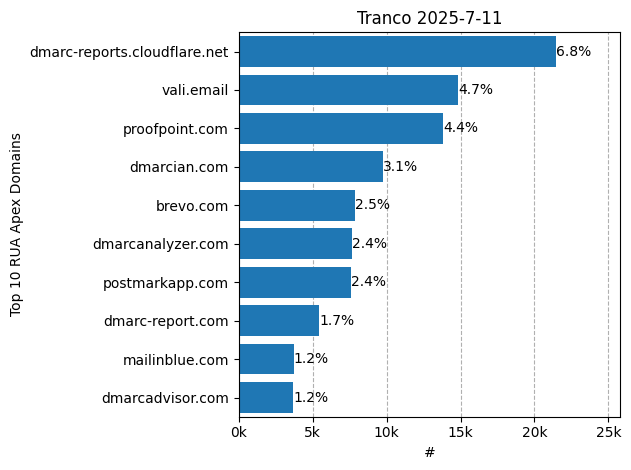

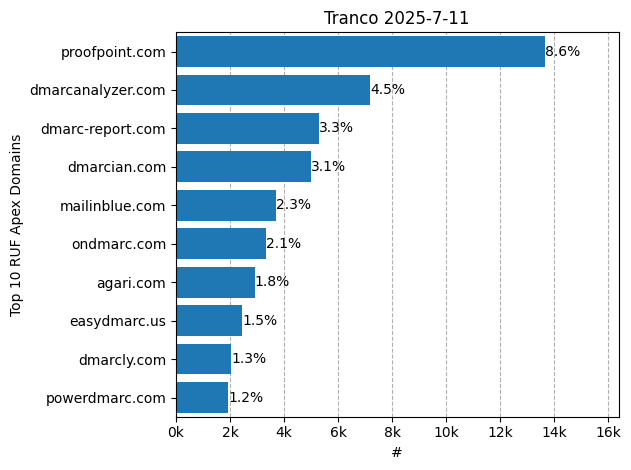

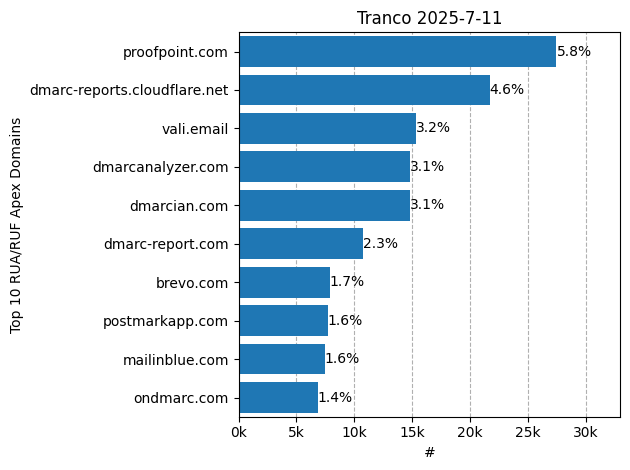

In [ ]:
def _plot_dmarc_ruaruf_tag(top_n, domain_tag, ylabel, start_date):
    plt.figure()

    _ = plt.barh(top_n[domain_tag], top_n["count"])
    for i, (count, percent) in enumerate(zip(top_n["count"], top_n["percent"])):
        plt.text(count + 1, i, f'{percent:.1f}%', va='center', ha='left')

    plt.title(f"Tranco {start_date.year}-{start_date.month}-{start_date.day}")
    plt.xlabel("#")
    plt.ylabel(ylabel)
    plt.xlim(0, top_n["count"].max() * 1.2)
    thousands = ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
    plt.gca().xaxis.set_major_formatter(thousands)
    plt.gca().set_axisbelow(True)
    plt.gca().xaxis.grid(True, linestyle='--')

    num_categories = len(top_n)
    plt.ylim(-.5, num_categories - .5)  # Minimal padding
    plt.gca().invert_yaxis()  # To show highest values at top

    plt.tight_layout()
    plt.savefig(f"figures/{domain_tag}_proportion.pdf", bbox_inches='tight')
    plt.show()


_plot_dmarc_ruaruf_tag(aggr_rua_pdf.head(10), "rua_apex_domain", "Top 10 rua Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_ruf_pdf.head(10), "ruf_apex_domain", "Top 10 ruf Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_rua_ruf_pdf.head(10), "rua_ruf_apex_domain", "Top 10 rua/ruf Apex Domains", start_date)

The plot is considering all tranco, not only ccTLDs...  

top 10 are all organisations (no individuals/admins)   
dmarc-report.com - doesn't exist  
postmarkapp.com - email delivery company  
cloudflare - cdn with email sec service  
the rest are email security companies.  

related work: proofpoint.com, reportdmarc.nl, mailingblue.com, agari.com, dmarcanalyzer.com, 163.com, dmarcian.com, dmarc-report.com, amazon.com, cloudflare.net, vali.email, gmail.com, secureserver.net, cisco.com, dmarcadvisor.com, domeneshop.no, postmarkapp.com, ondmarc.com, barracudanetworks.com, microhost.pl  